# Pixel-Wise Image Similarity Metric

In [314]:
import pandas as pd
from sklearn.metrics import mean_absolute_error
import numpy as np
from sklearn.model_selection import train_test_split
from scipy import stats
import numpy as np, pandas as pd, librosa, librosa.display
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
def get_age_ssim_changes(vid, n_sec=3, method=linear_power_spec):
  sp = (features[features["VoxCeleb_ID"] == vid]
          .drop_duplicates(subset=["age_vid_id"])
          [META]
          .sort_values(by="speaker_age")
          .reset_index(drop=True))

  if len(sp) < 2:
      return pd.DataFrame()

  ref_spec     = method(sp.wav_path.iloc[0], n_sec)
  youngest_age = sp.speaker_age.iloc[0]
  results = []

  for i in range(1, len(sp)):
      cur_spec = method(sp.wav_path.iloc[i], n_sec)
      min_f = min(ref_spec.shape[0], cur_spec.shape[0])
      min_t = min(ref_spec.shape[1], cur_spec.shape[1])
      a = ref_spec[:min_f, :min_t]
      b = cur_spec[:min_f, :min_t]
      dr = max(a.max()-a.min(), b.max()-b.min())
      # win_size=3 for small matrices (chroma 12, tonnetz 6)
      win = 3 if min(a.shape) < 7 else 7
      score = ssim(a, b, data_range=dr, win_size=win)
      mse  = mean_squared_error(a, b)
      dr   = max(a.max()-a.min(), b.max()-b.min())
      nmse = mse / (dr**2 + 1e-12)               # normalized [0, 1]
      psnr = 10 * np.log10(dr**2 / (mse + 1e-12)) # dB
      results.append({
          "VoxCeleb_ID":      vid,
          "speaker_age":      sp.speaker_age.iloc[i],
          "age_diff":         sp.speaker_age.iloc[i] - youngest_age,
          "video_id":         sp.video_id.iloc[i],
          "wav_path":         sp.wav_path.iloc[i],
          "ssim_vs_youngest": score,
          "mse_vs_youngest":  mse,
          "nmse_vs_youngest": nmse,
          "psnr_vs_youngest": psnr,
      })
  return pd.DataFrame(results)

from scipy import stats
import numpy as np
import pandas as pd
from tqdm import tqdm

def fill_persons_all_methods(persons, sec, method=linear_power_spec):
  """Pearson per speaker for SSIM and MSE — separate r and p."""
  speakers = persons["VoxCeleb_ID"].unique()
  persons_ssim_dict = {vid: get_age_ssim_changes(vid, sec, method)
                        for vid in tqdm(speakers, desc=f'SSIM @ {sec}s')}

  # NaN row — all 4 columns we normally fill
  nan_row = {
      f"pearson_ssim_r_{sec}": np.nan,
      f"pearson_ssim_p_{sec}": np.nan,
      f"pearson_mse_r_{sec}":  np.nan,
      f"pearson_mse_p_{sec}":  np.nan,
  }

  rows = []
  for vid in speakers:
      df = persons_ssim_dict[vid]
      row = {"VoxCeleb_ID": vid}

      if (len(df) >= 2
          and df["age_diff"].std() > 0
          and df["ssim_vs_youngest"].std() > 0
          and df["mse_vs_youngest"].std() > 0):
          try:
              # SSIM
              res_ssim = stats.pearsonr(df["age_diff"], df["ssim_vs_youngest"])
              row[f"pearson_ssim_r_{sec}"] = res_ssim.statistic
              row[f"pearson_ssim_p_{sec}"] = res_ssim.pvalue

              # MSE — use res_mse, NOT res_ssim
              res_mse = stats.pearsonr(df["age_diff"], df["mse_vs_youngest"])
              row[f"pearson_mse_r_{sec}"] = res_mse.statistic
              row[f"pearson_mse_p_{sec}"] = res_mse.pvalue

          except Exception as e:
              print(f"{vid}: {type(e).__name__}: {e}")
              row.update(nan_row)
      else:
          row.update(nan_row)

      rows.append(row)

  corr_df = pd.DataFrame(rows)
  return persons.merge(corr_df, on="VoxCeleb_ID", how="left")


from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error
import numpy as np
import pandas as pd
from tqdm import tqdm


def get_extremes_distance(vid, n_sec=3, method=linear_power_spec):
  """SSIM and MSE between the YOUNGEST and OLDEST recording of a speaker.

  Returns a dict, or None when <2 recordings.
  """
  sp = (features[features["VoxCeleb_ID"] == vid]
          .drop_duplicates(subset=["age_vid_id"])
          [META]
          .sort_values(by="speaker_age")
          .reset_index(drop=True))

  if len(sp) < 2:
      return None

  young_spec = method(sp.wav_path.iloc[0],  n_sec)
  old_spec   = method(sp.wav_path.iloc[-1], n_sec)

  # Safety crop
  min_f = min(young_spec.shape[0], old_spec.shape[0])
  min_t = min(young_spec.shape[1], old_spec.shape[1])
  a = young_spec[:min_f, :min_t]
  b = old_spec[:min_f, :min_t]

  dr  = max(a.max() - a.min(), b.max() - b.min())
  win = 3 if min(a.shape) < 7 else 7

  return {
      "VoxCeleb_ID":  vid,
      "age_youngest": sp.speaker_age.iloc[0],
      "age_oldest":   sp.speaker_age.iloc[-1],
      "age_range":    sp.speaker_age.iloc[-1] - sp.speaker_age.iloc[0],
      "n_recordings": len(sp),
      "ssim_extremes": ssim(a, b, data_range=dr, win_size=win),
      "mse_extremes":  mean_squared_error(a, b),
  }

def fill_persons_extremes(persons, sec, method=linear_power_spec):
  """For each speaker: SSIM and MSE between the youngest and oldest recording.

  Resulting columns:
    - age_youngest_{sec}
    - age_oldest_{sec}
    - age_range_{sec}
    - n_recordings_{sec}
    - ssim_extremes_{sec}
    - mse_extremes_{sec}
  """
  speakers = persons["VoxCeleb_ID"].unique()

  rows = []
  for vid in tqdm(speakers, desc=f'Extremes @ {sec}s'):
      try:
          r = get_extremes_distance(vid, sec, method)
          if r is None:
              rows.append({"VoxCeleb_ID": vid})    # only VID, the rest NaN after merge
          else:
              rows.append(r)
      except Exception as e:
          print(f"{vid}: {type(e).__name__}: {e}")
          rows.append({"VoxCeleb_ID": vid})

  ext_df = pd.DataFrame(rows)

  # Rename columns to include sec
  rename_map = {
      "age_youngest":   f"age_youngest_{sec}",
      "age_oldest":     f"age_oldest_{sec}",
      "age_range":      f"age_range_{sec}",
      "n_recordings":   f"n_recordings_{sec}",
      "ssim_extremes":  f"ssim_extremes_{sec}",
      "mse_extremes":   f"mse_extremes_{sec}",
  }
  ext_df = ext_df.rename(columns=rename_map)

  return persons.merge(ext_df, on="VoxCeleb_ID", how="left")



In [352]:
def _load(wav_path, n_sec):
    y, _ = librosa.load(wav_path, sr=SR, mono=True, duration=n_sec)
    return y / (np.max(np.abs(y)) + 1e-9)


def extract_all_5(wav_path, n_sec):
    return {
        'linear_power':   linear_power_spec(wav_path, n_sec),
        'log_freq_power': log_freq_power_spec(wav_path, n_sec),
        'cqt_power':      cqt_power_spec(wav_path, n_sec),
        'chromagram':     chromagram(wav_path, n_sec),
        'tempogram':      tempogram(wav_path, n_sec),
    }
from scipy.stats import pearsonr

import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error
from skimage import data, img_as_float

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.pyplot as plt
def get_image(frame, title, method):
  """R-value histograms per gender (sec 1-5), Female vs Male."""
  secs = [1, 2, 3, 4, 5]
  genders = ["female", "male"]

  # one row (Female, Male) for the "r" value
  rows_spec = [
      (f"R — {g.capitalize()}", g) for g in genders
  ]

  n_rows = len(rows_spec)
  fig, axes = plt.subplots(n_rows, len(secs),
                           figsize=(15, 3 * n_rows), sharey="row")
  axes = axes.reshape(n_rows, -1)          # also works for n_rows == 1

  for row, (rlabel, gender) in enumerate(rows_spec):
      for col_idx, sec in enumerate(secs):
          col = f"pearson_{method}_r_{sec}"
          if col not in frame.columns:
              axes[row, col_idx].set_title(f"{col} MISSING", fontsize=9)
              continue

          data = frame[frame.gender == gender][col].dropna()
          axes[row, col_idx].hist(data, bins=10)
          axes[row, col_idx].set_title(col, fontsize=9)
          axes[row, col_idx].axvline(0.0, color='red', linestyle='--', alpha=0.5)
          axes[row, col_idx].grid(alpha=0.3, axis='y')
      axes[row, 0].set_ylabel(rlabel, fontweight='bold')

  fig.suptitle(f"{title} — R-value (sec 1-5) — F vs M", fontsize=14)
  plt.tight_layout()
  plt.show()



def get_image_box(frame, title, metric="ssim", corr="pearson", value="r"):
  """Boxplot of R or P value per gender"""
  secs = [1, 2, 3, 4, 5]
  fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

  hline = 0.0 if value == "r" else 0.05

  for col_idx, sec in enumerate(secs):
      col = f"{corr}_{metric}_{value}_{sec}"
      if col not in frame.columns:
          continue

      data = [
          frame[frame.gender == "male"][col].dropna(),
          frame[frame.gender == "female"][col].dropna(),
      ]
      axes[col_idx].boxplot(data, tick_labels=["M", "F"], showmeans=True,
                            meanprops={"marker": "D", "markerfacecolor": "red"})
      axes[col_idx].axhline(hline, color='red', linestyle='--', alpha=0.5)
      axes[col_idx].set_title(col, fontsize=9)
      axes[col_idx].grid(alpha=0.3, axis='y')

  fig.suptitle(f"{title} — {metric.upper()} ({corr}) — {value.upper()}-value per gender (boxplot)",
               fontsize=14)
  plt.tight_layout()
  plt.show()

    
def get_image_extremes(frame, title, metric="ssim"):
  """Histogram SSIM/MSE_extremes per gender

  Works on a DataFrame with columns ssim_extremes_{sec} and mse_extremes_{sec}.
  """
  secs = [1, 2, 3, 4, 5]
  fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey="row")

  for col_idx, sec in enumerate(secs):
      col = f"{metric}_extremes_{sec}"
      if col not in frame.columns:
          for row_idx in range(2):
              axes[row_idx, col_idx].set_title(f"{col} MISSING", fontsize=9)
          continue

      for row_idx, gender in enumerate(["male", "female"]):
          data = frame[frame.gender == gender][col].dropna()
          axes[row_idx, col_idx].hist(data, bins=20)
          axes[row_idx, col_idx].set_title(col, fontsize=9)
          axes[row_idx, col_idx].axvline(
              data.median(), color='red', linestyle='--', alpha=0.5
          )
          axes[row_idx, col_idx].grid(alpha=0.3, axis='y')

  axes[0, 0].set_ylabel("Male",   fontweight='bold')
  axes[1, 0].set_ylabel("Female", fontweight='bold')
  fig.suptitle(f"{title} — {metric.upper()}_extremes per gender", fontsize=14)
  plt.tight_layout()
  plt.show()
def get_image_box_extremes(frame, title, metric="ssim"):
  """Boxplot SSIM/MSE_extremes gender"""
  secs = [1, 2, 3, 4, 5]
  fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

  for col_idx, sec in enumerate(secs):
      col = f"{metric}_extremes_{sec}"
      if col not in frame.columns: continue

      data = [
          frame[frame.gender == "male"][col].dropna(),
          frame[frame.gender == "female"][col].dropna(),
      ]
      axes[col_idx].boxplot(data, tick_labels=["M", "F"], showmeans=True,
                              meanprops={"marker":"D", "markerfacecolor":"red"})
      axes[col_idx].set_title(col, fontsize=9)
      axes[col_idx].grid(alpha=0.3, axis='y')

  fig.suptitle(f"{title} — {metric.upper()}_extremes per gender (boxplot)", fontsize=14)
  plt.tight_layout()
  plt.show()



def filter_low_p(df, threshold=0.3, secs=(1, 2, 3, 4, 5),
               corr="pearson", metric="ssim"):
  """Returns speakers whose p-values are ALL < threshold.

  Column name construction: {corr}_{metric}_p_{sec}
  e.g. pearson_ssim_p_3, spearman_mse_p_5
  """
  result = df.copy()
  for sec in secs:
      # Build column name with optional metric
      if metric:
          col = f"{corr}_{metric}_p_{sec}"
      else:
          col = f"{corr}_p_{sec}"   # legacy fallback

      if col in result.columns:
          result = result[result[col] < threshold]
      else:
          print(f"⚠ Missing column: {col}")
  return result


def fill_persons(persons, sec):
  """For each speaker in `persons` compute Pearson r/p between age_diff and SSIM.

  Modifies `persons` in-place, adding columns:
    - pearson_r_{sec}
    - pearson_p_{sec}
  Returns persons (for chaining convenience).
  """
  colname_r = f"pearson_r_{sec}"
  colname_p = f"pearson_p_{sec}"

  # 1) Compute SSIM changes per speaker (once, cached in dict)
  speakers = persons["VoxCeleb_ID"].unique()
  persons_ssim_dict = {}
  for vid in tqdm(speakers, desc=f'SSIM @ {sec}s'):
      persons_ssim_dict[vid] = get_age_ssim_changes(vid, sec)

  # 2) Pearson per speaker
  r_map, p_map = {}, {}
  for vid in speakers:
      df_ssim = persons_ssim_dict[vid]
      try:
          if len(df_ssim) < 2:
              raise ValueError("too few points")
          r, p = pearsonr(df_ssim["age_diff"], df_ssim["ssim_vs_youngest"])
          r_map[vid], p_map[vid] = r, p
      except (ValueError, KeyError):
          r_map[vid], p_map[vid] = np.nan, np.nan

  # 3) Map back onto persons
  persons[colname_r] = persons["VoxCeleb_ID"].map(r_map)
  persons[colname_p] = persons["VoxCeleb_ID"].map(p_map)
  return persons


In [ ]:
# read data from  step 2 

In [9]:
features = pd.read_pickle("features.pkl")
SR, N_FFT, HOP = 16000, 2048, 128
OUT_DIR = Path('ssim_arrays')
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [10]:
features["age_vid_id"]=features["VoxCeleb_ID"]+"_"+features["video_id"]+"_"+features["speaker_age"].astype(str)

In [11]:
META=['VoxCeleb_ID', 'video_id', 'gender', 'speaker_age', 'wav_path','age_vid_id']
FEATS = [c for c in features.columns if c not in META]


In [318]:
# all infromation are extracted from features in each step

In [12]:
persons = features.drop_duplicates(subset=["VoxCeleb_ID"])
persons=persons[META]

## methods

In [323]:
sample = persons.wav_path.values[0]
sample

'/data/VoxCeleb2/id07334/t1emVSapJyc/00226.wav'

In [330]:
def get_librosa_image(cur_spec,title):
    fig, ax = plt.subplots(figsize=(10, 4))
    img_lin_db_age_sum = librosa.display.specshow(cur_spec, sr=SR, hop_length=HOP, x_axis='time', y_axis='linear', ax=ax)
    ax.set_title(f'{title} ({n_sec:g}s)')
    fig.colorbar(img_lin_db_age_sum, ax=ax, format='%+2.0f dB'); plt.tight_layout(); plt.show()

### linear_power_spec

In [331]:

def linear_power_spec(wav_path, n_sec):
    y = _load(wav_path, n_sec)
    return librosa.power_to_db(np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP))**2, ref=np.max)


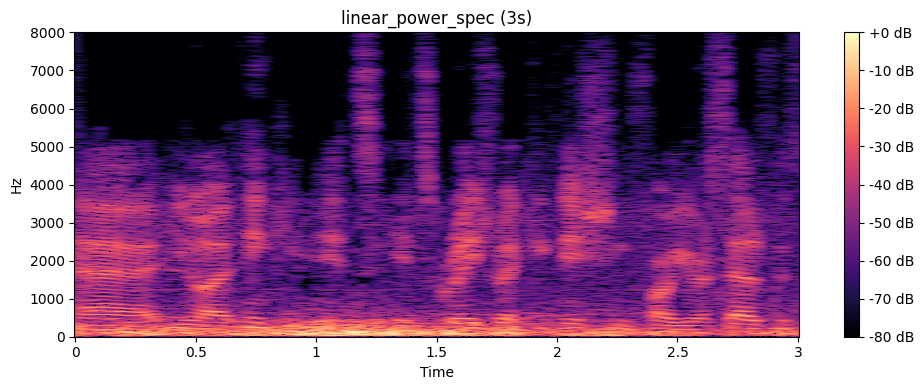

In [332]:

cur_spec = linear_power_spec(sample, 3)
get_librosa_image(cur_spec,"linear_power_spec")

### cqt_power_spec

In [322]:
def cqt_power_spec(wav_path, n_sec):
    y = _load(wav_path, n_sec)
    cqt = librosa.cqt(y, sr=SR, hop_length=HOP, n_bins=84, bins_per_octave=12)
    return librosa.power_to_db(np.abs(cqt)**2, ref=np.max)


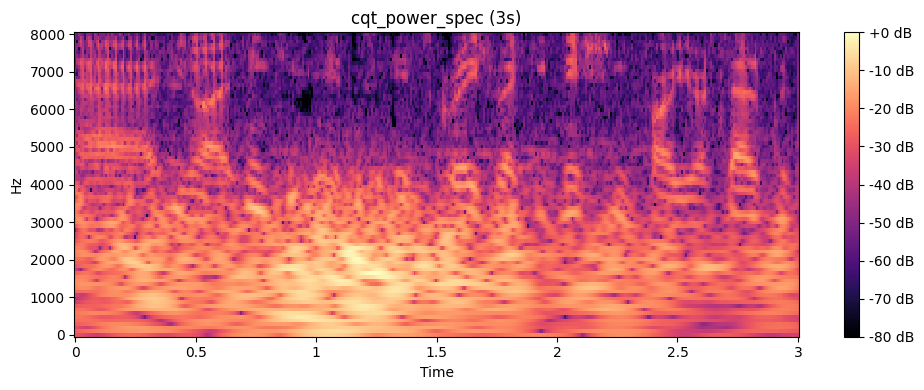

In [333]:

cur_spec = cqt_power_spec(sample, 3)
get_librosa_image(cur_spec,"cqt_power_spec")

### chromagram

In [326]:

def chromagram(wav_path, n_sec):
    return librosa.feature.chroma_cqt(y=_load(wav_path, n_sec), sr=SR, hop_length=HOP)


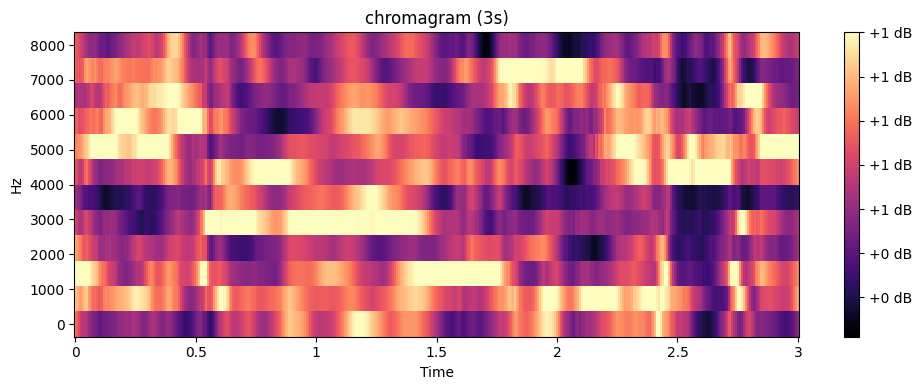

In [334]:

cur_spec = chromagram(sample, 3)
get_librosa_image(cur_spec,"chromagram")

### tempogram

In [335]:

def tempogram(wav_path, n_sec):
    
    y = _load(wav_path, n_sec)
    oenv = librosa.onset.onset_strength(y=y, sr=SR, hop_length=HOP)
    win = min(384, max(16, len(oenv) // 2))
    return librosa.feature.tempogram(onset_envelope=oenv, sr=SR, hop_length=HOP,win_length=win)


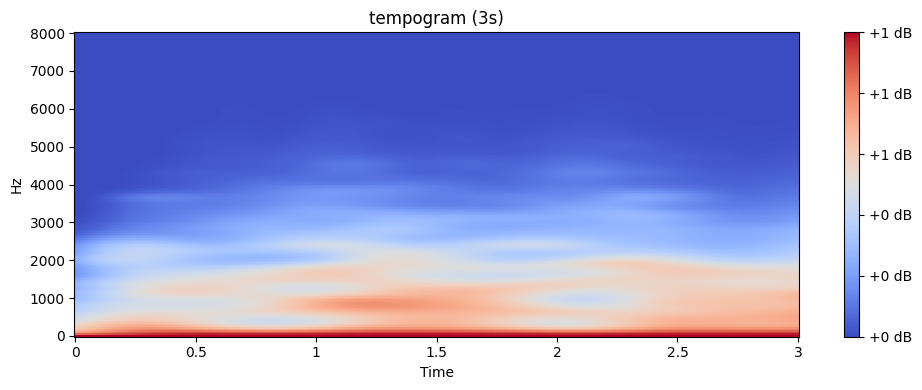

In [336]:
cur_spec = tempogram(sample, 3)
get_librosa_image(cur_spec,"tempogram")

## compute correlation during age SSIM and MSE

In [339]:
METHODS = {
  "linear":     linear_power_spec,
  "cqt":        cqt_power_spec,
  "chromagram": chromagram,
  "tempogram":  tempogram,
}



In [ ]:
results = {}
for name, fn in METHODS.items():
  df = persons.copy()
  for sec in [1, 2, 3, 4, 5]:
      df = fill_persons_all_methods(df, sec, method=fn)
  results[name] = df


In [338]:
persons_linear              = results["linear"]
persons_cqt_power_spec      = results["cqt"]
persons_chromagram          = results["chromagram"]
persons_tempogram           = results["tempogram"]

## compute MSE and SSIM between the youngest and oldest recording 

In [ ]:
ext_results = {}
for name, fn in METHODS.items():
  df = persons.copy()
  for sec in [1, 2, 3, 4, 5]:
      df = fill_persons_extremes(df, sec=sec, method=fn)
  ext_results[name] = df

In [340]:
persons_linear_ext     = ext_results["linear"]
persons_cqt_ext        = ext_results["cqt"]
persons_chromagram_ext = ext_results["chromagram"]
persons_tempogram_ext  = ext_results["tempogram"]

## Results

### SSIM and MSE between the youngest and oldest recordings for 1,2,3,4,5 sec audio duration 

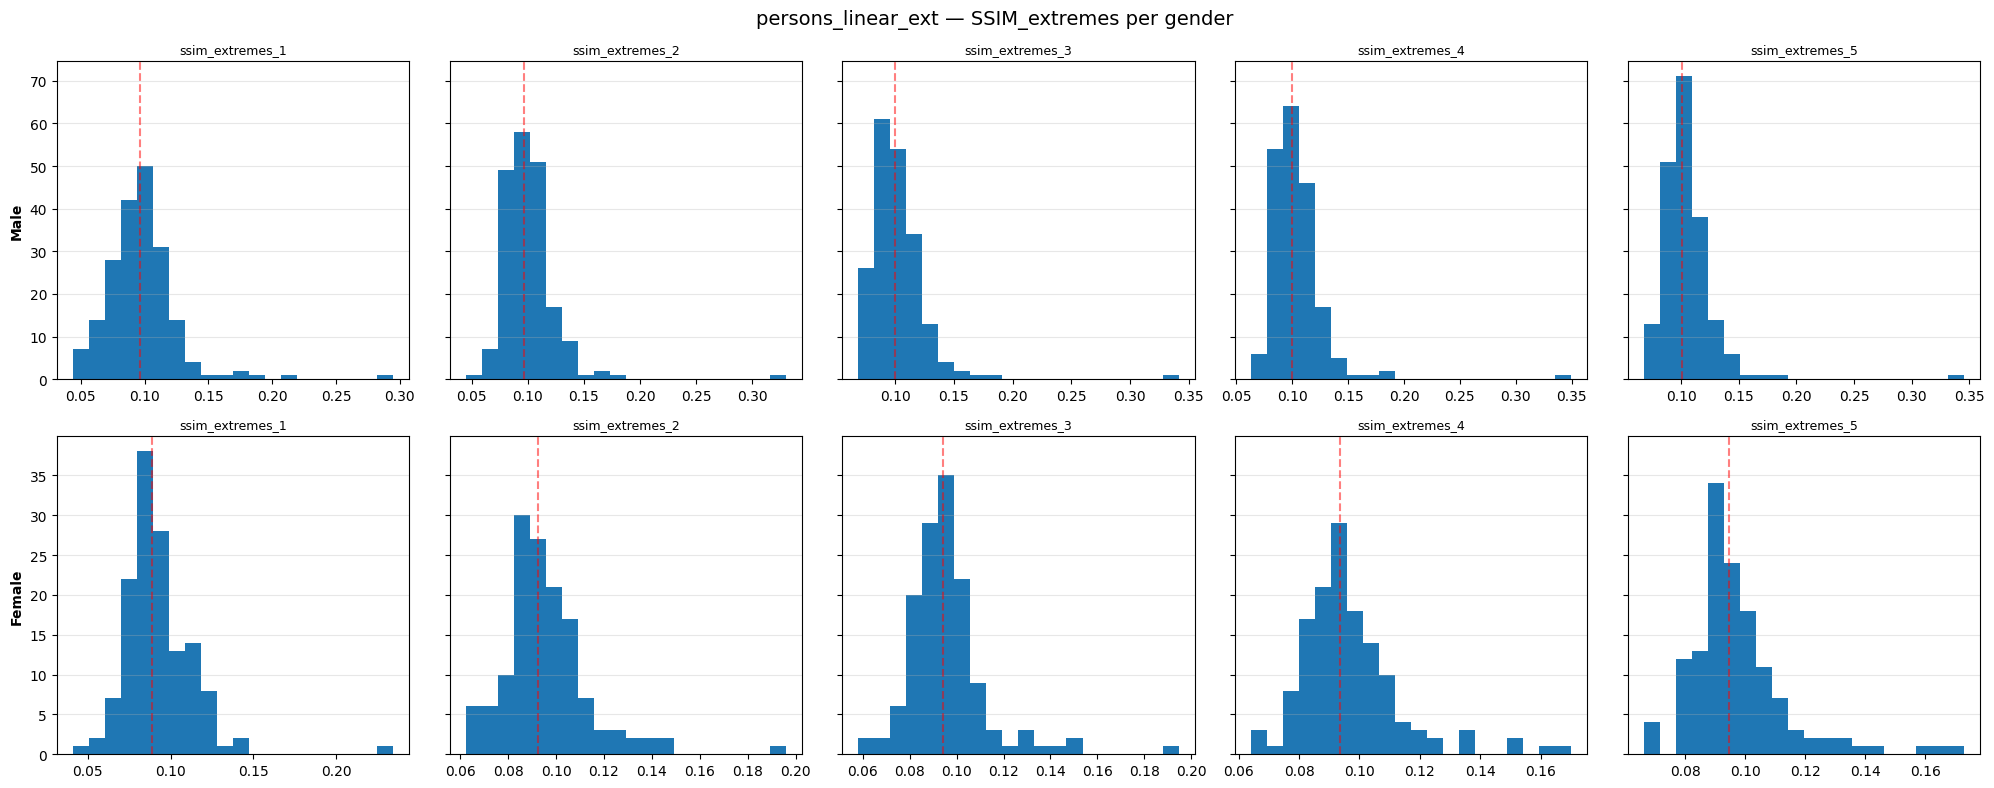

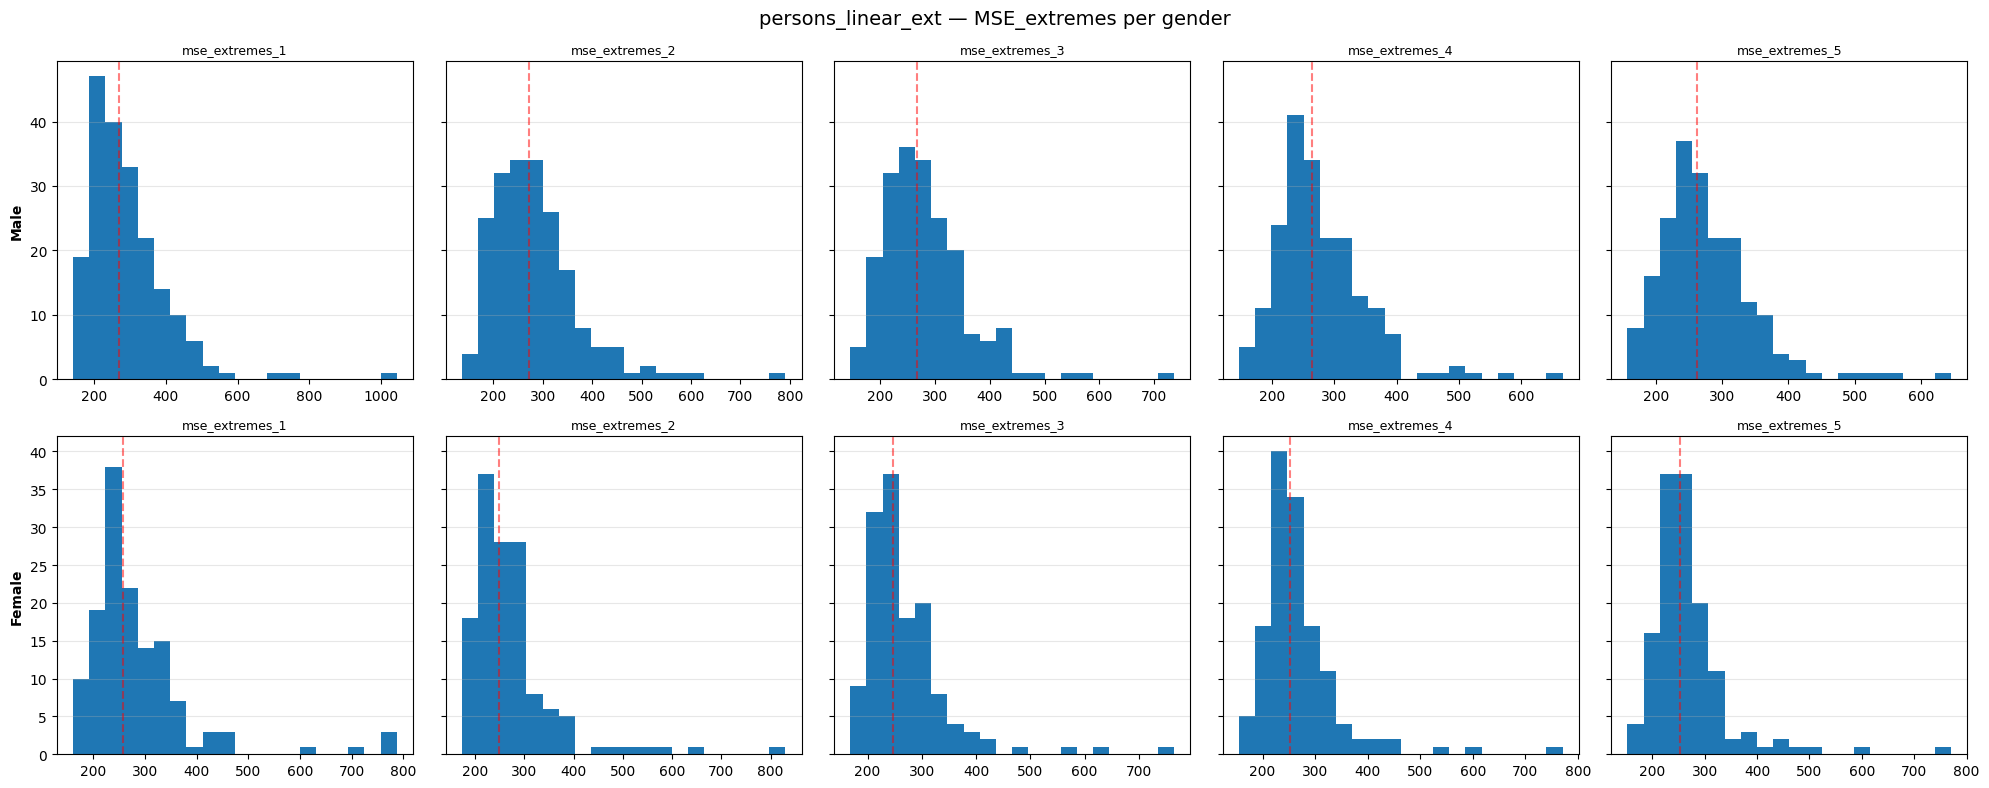

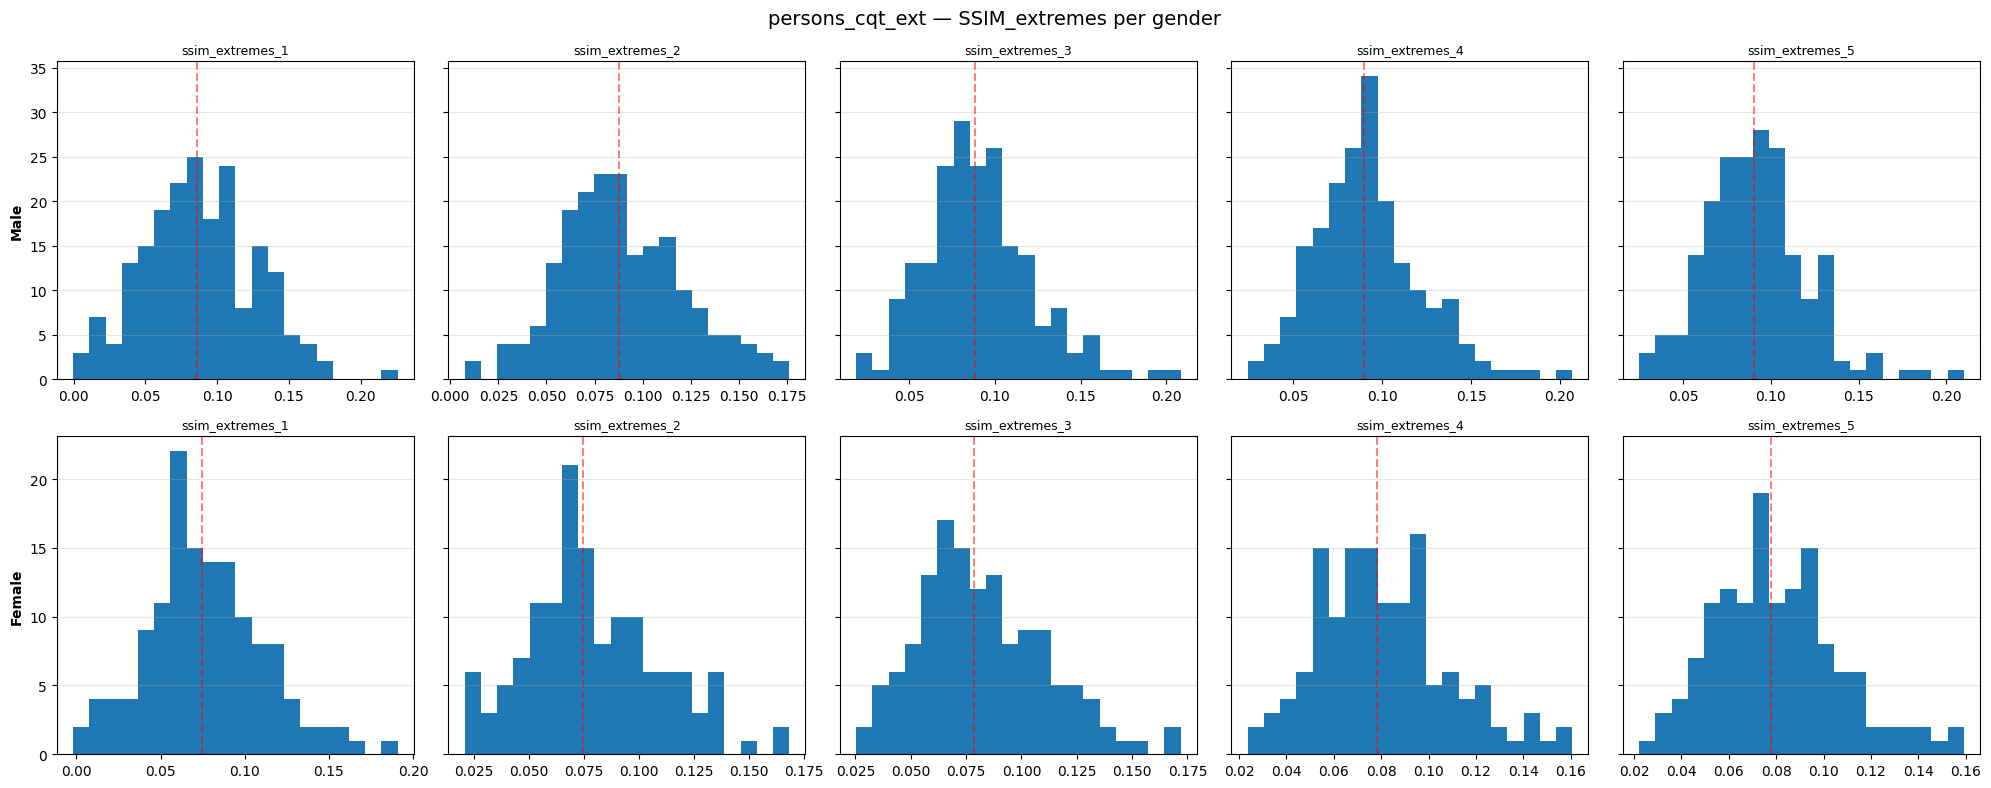

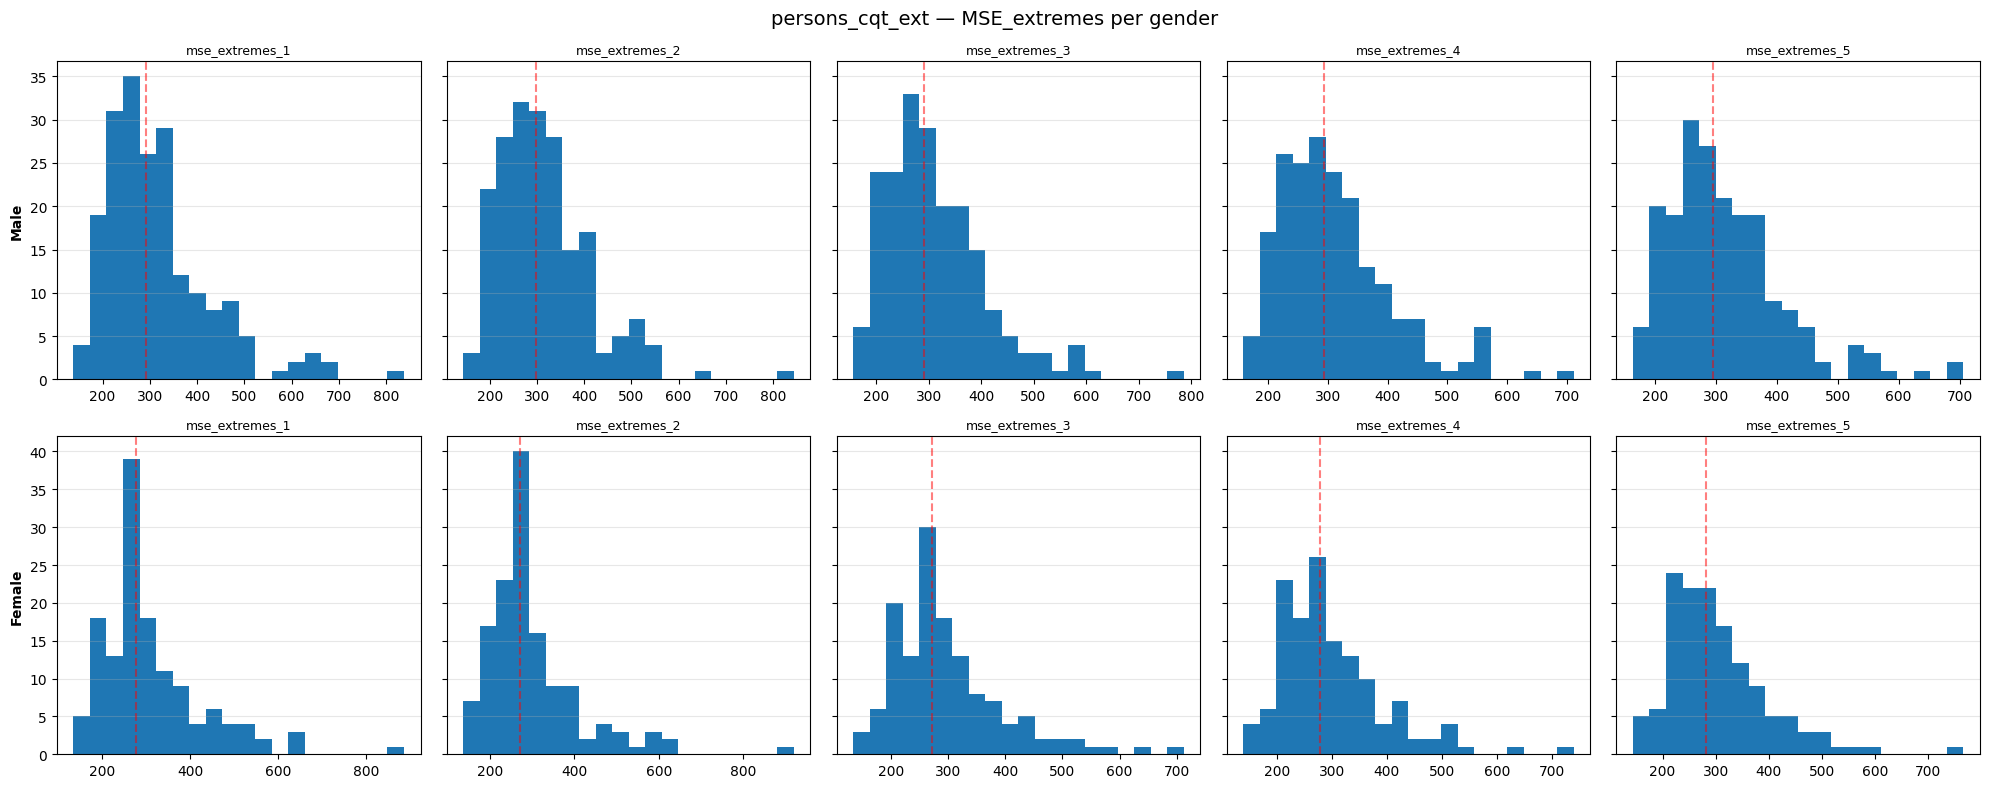

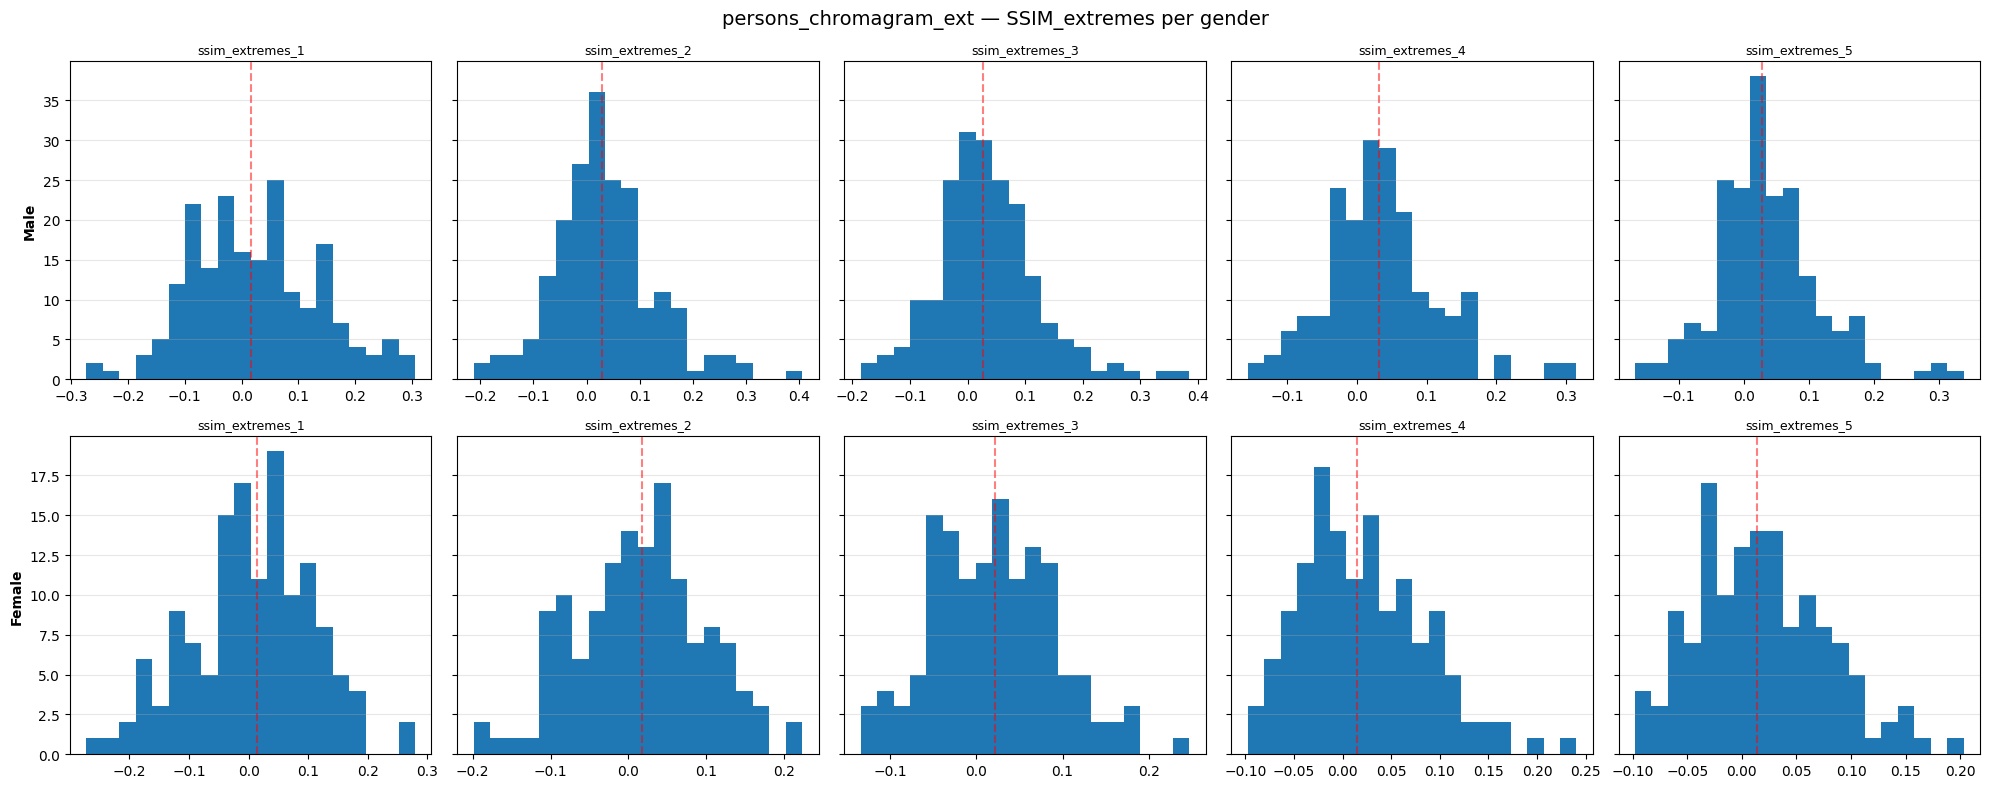

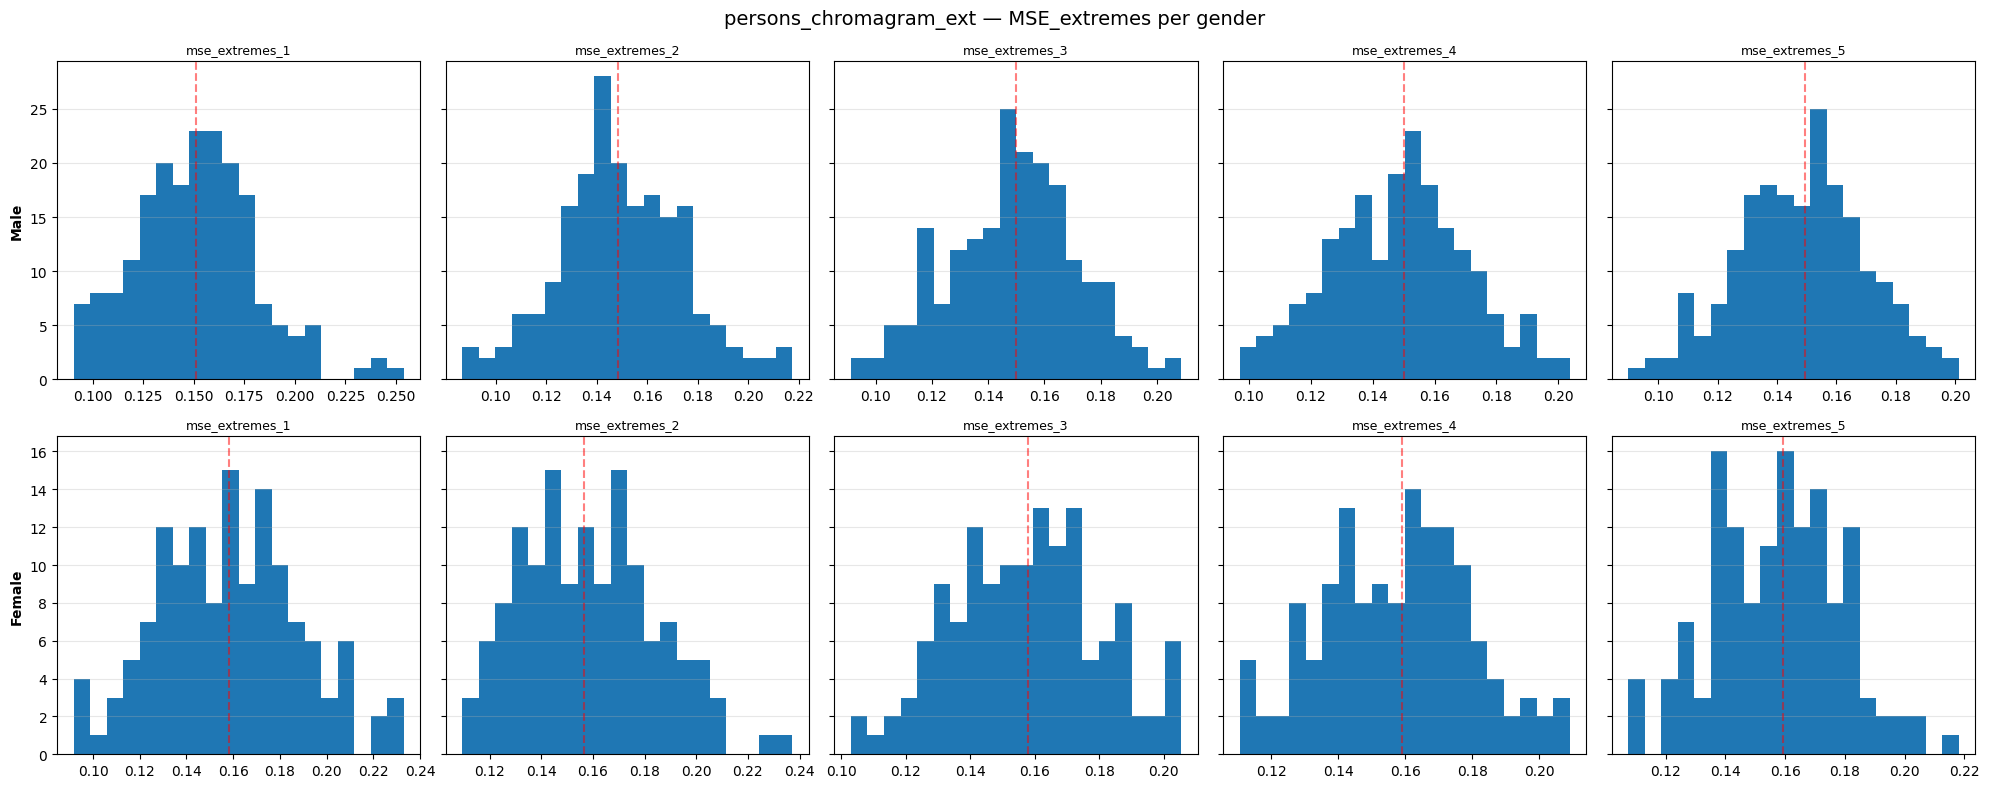

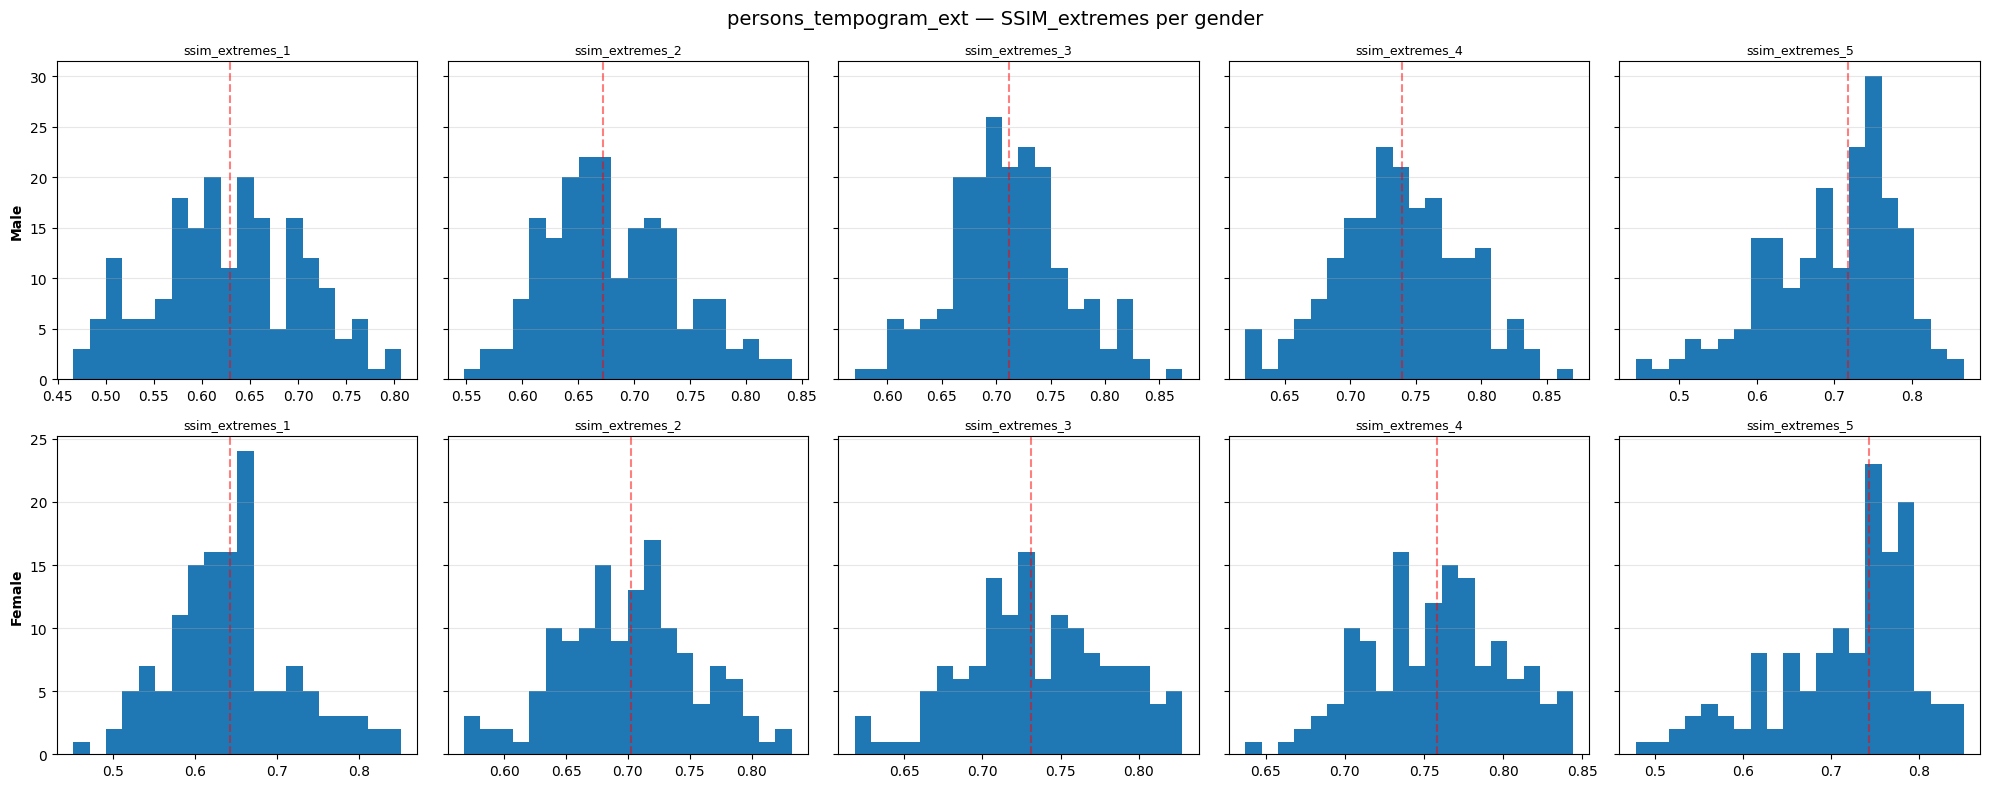

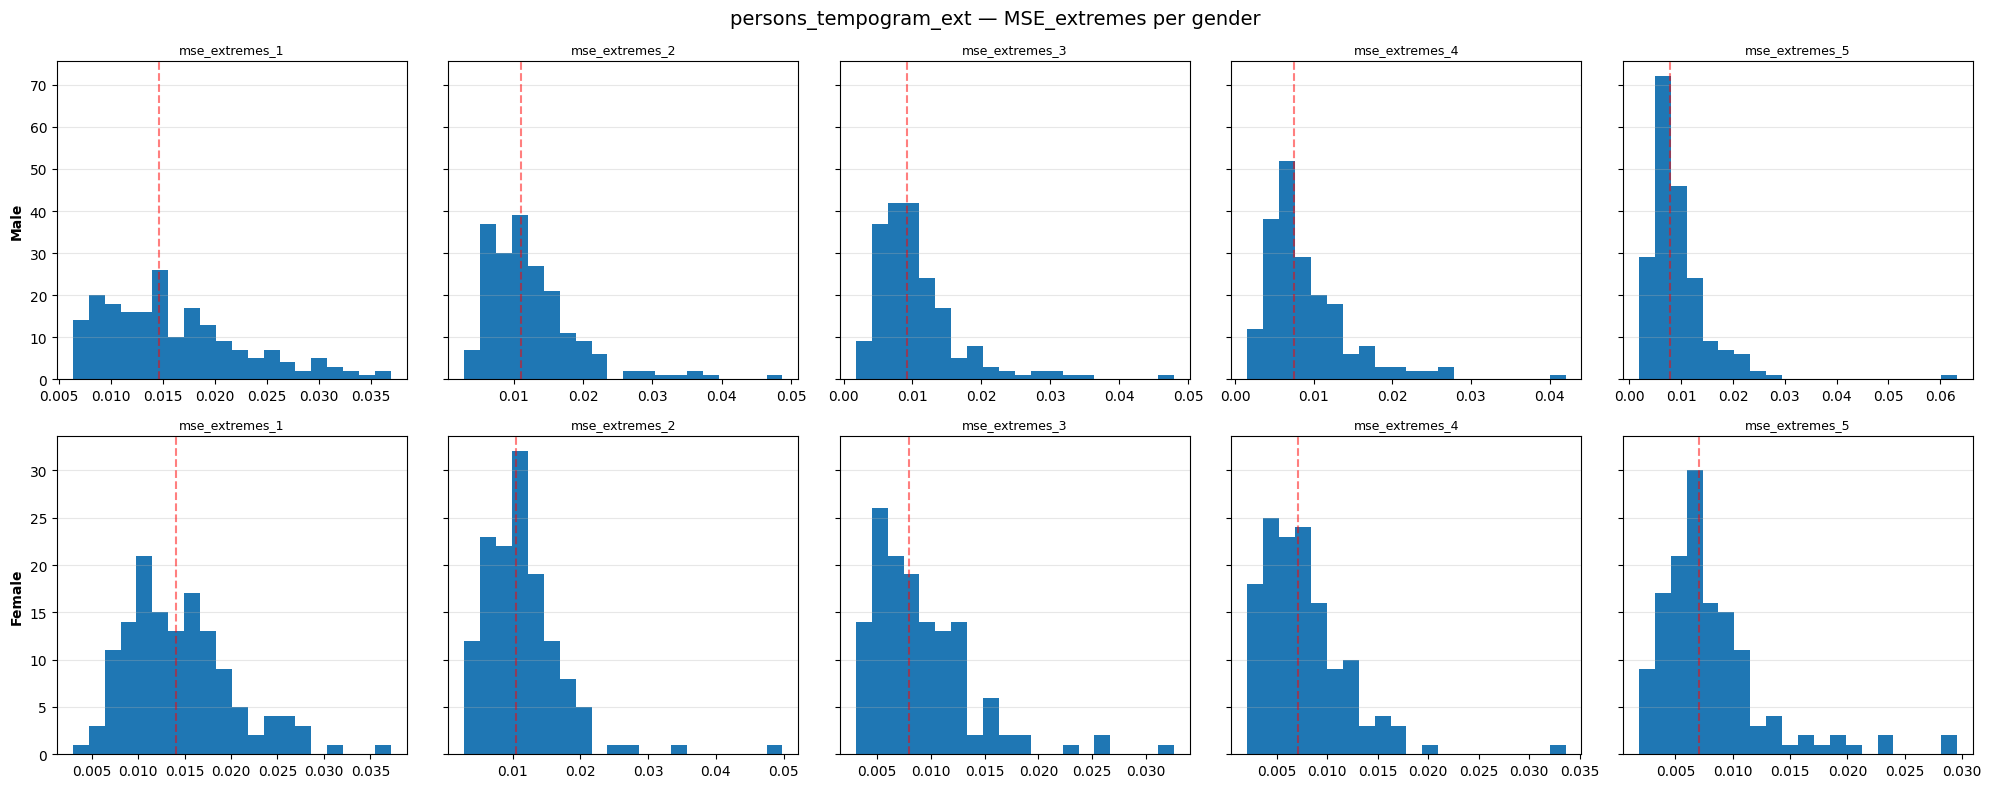

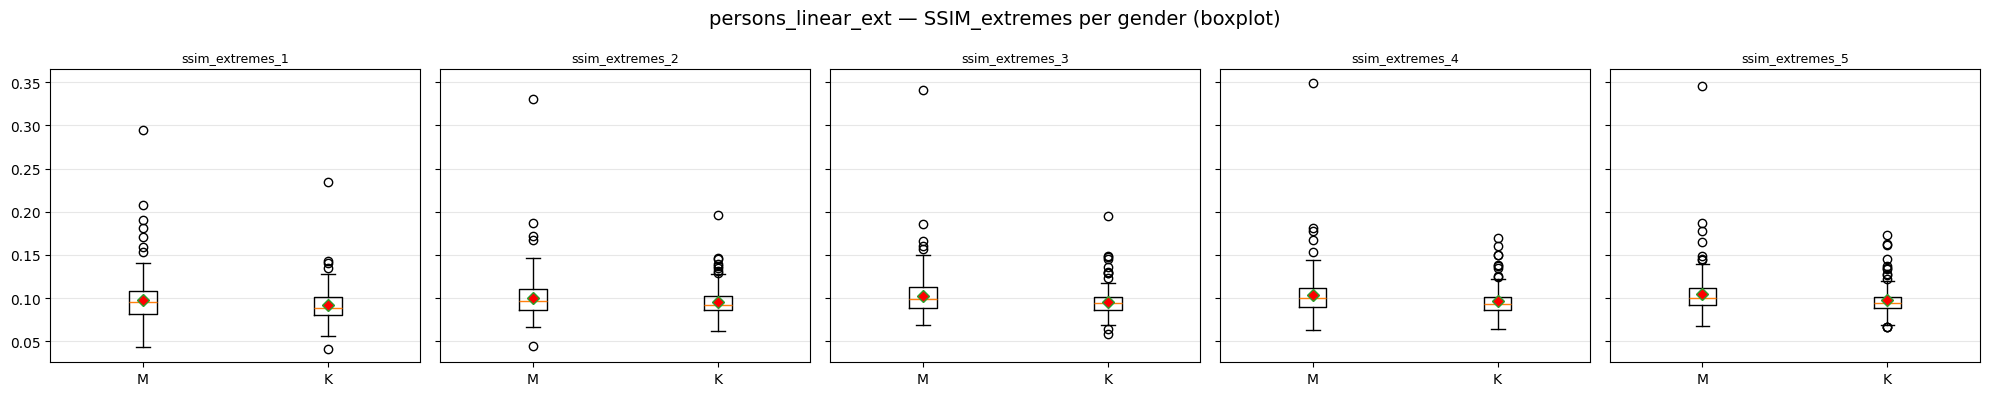

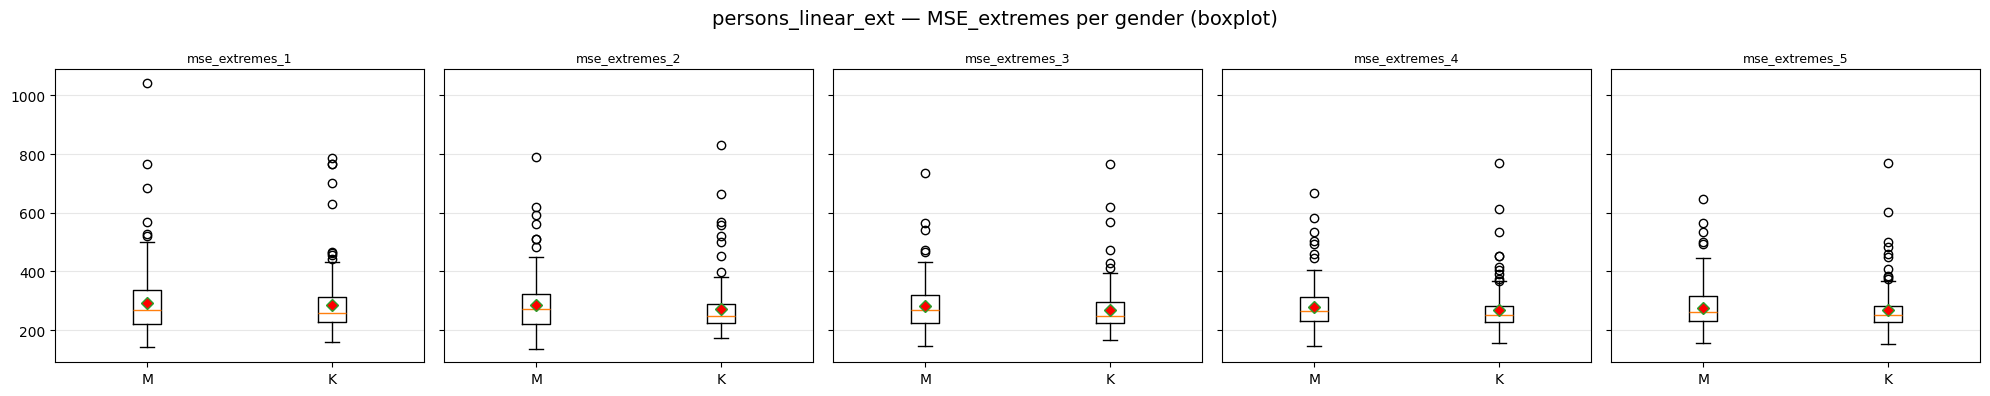

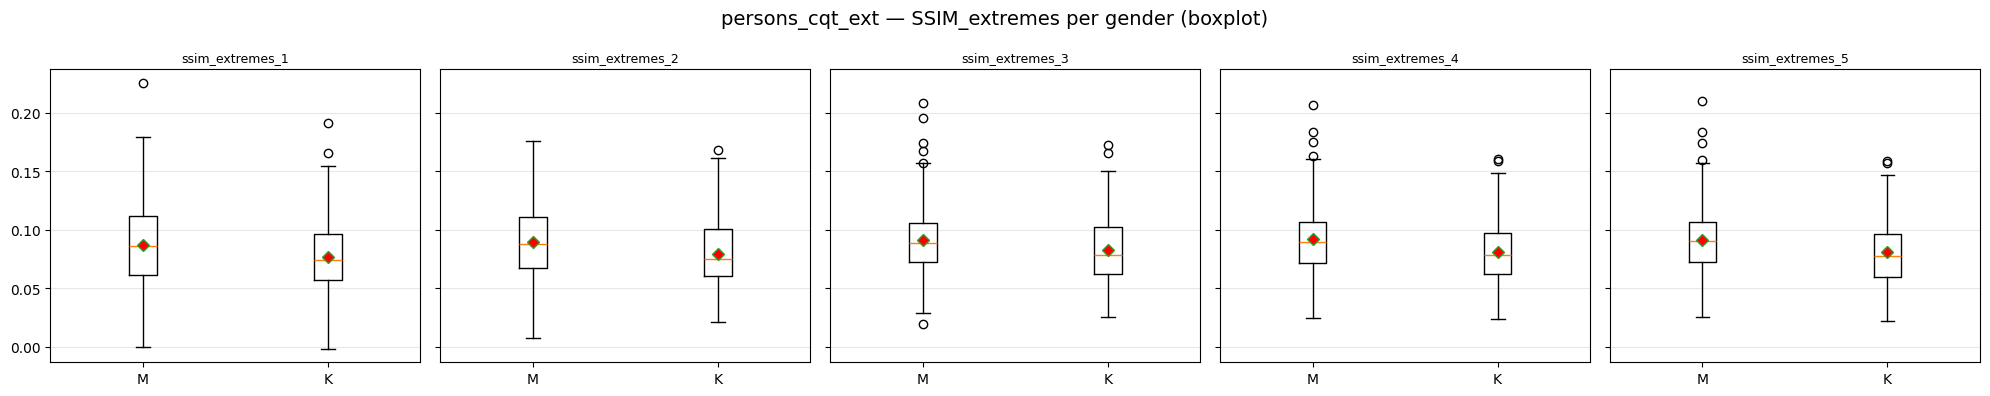

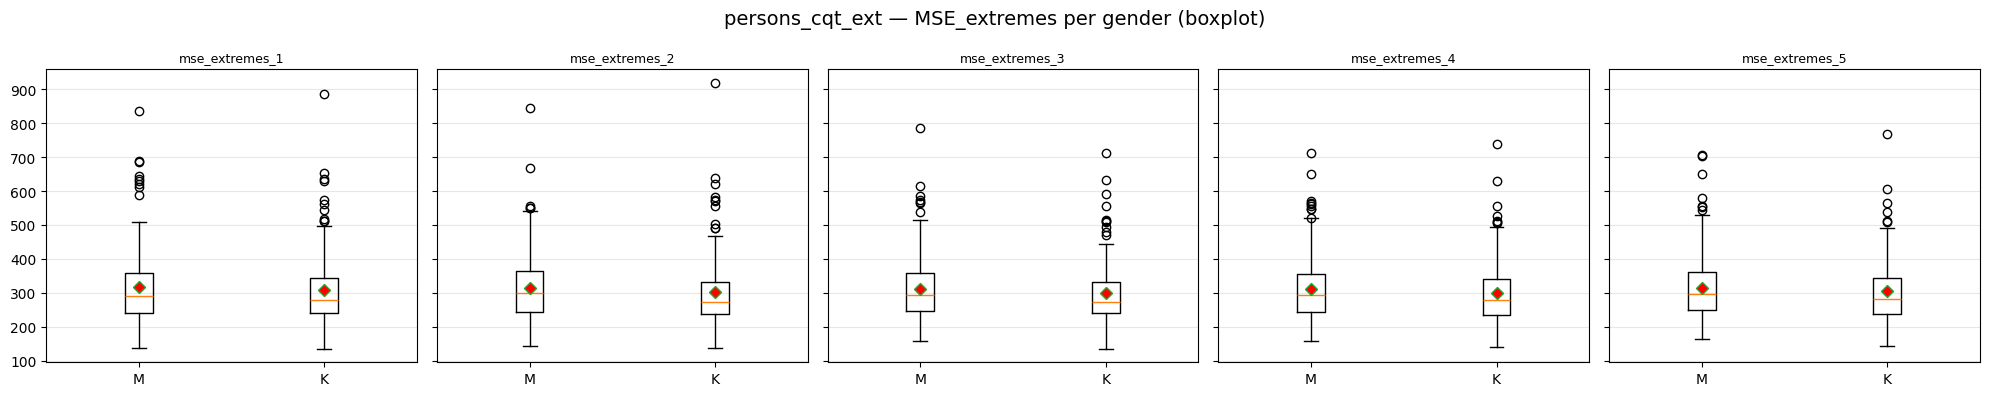

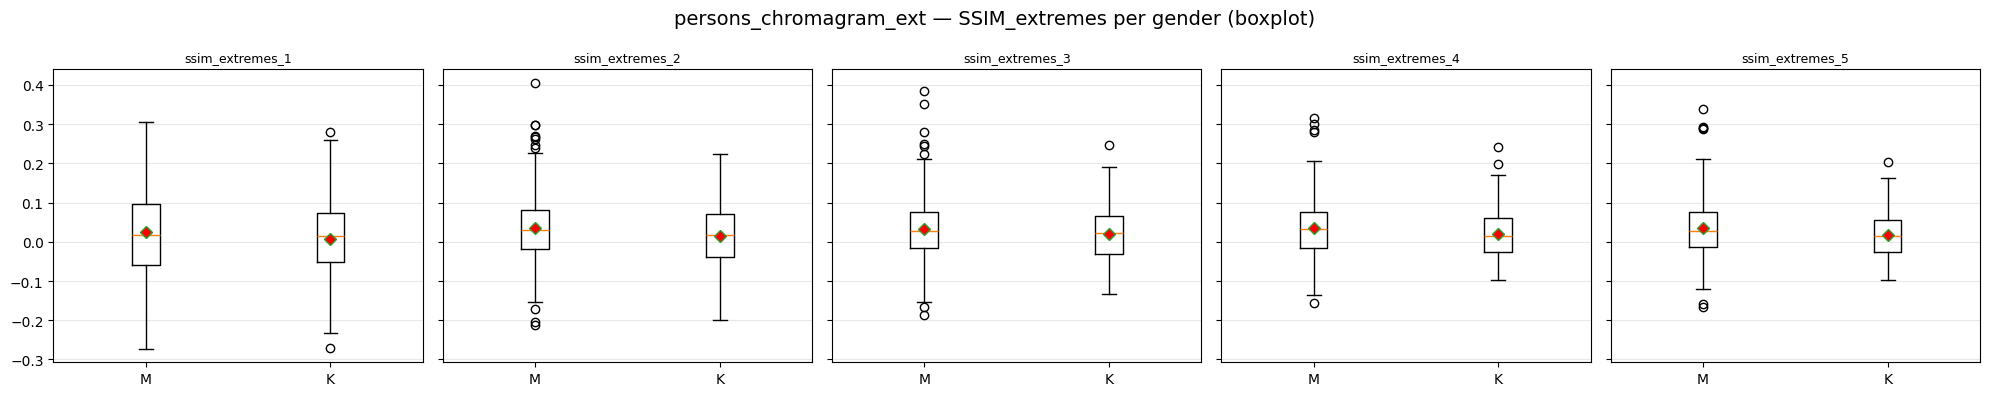

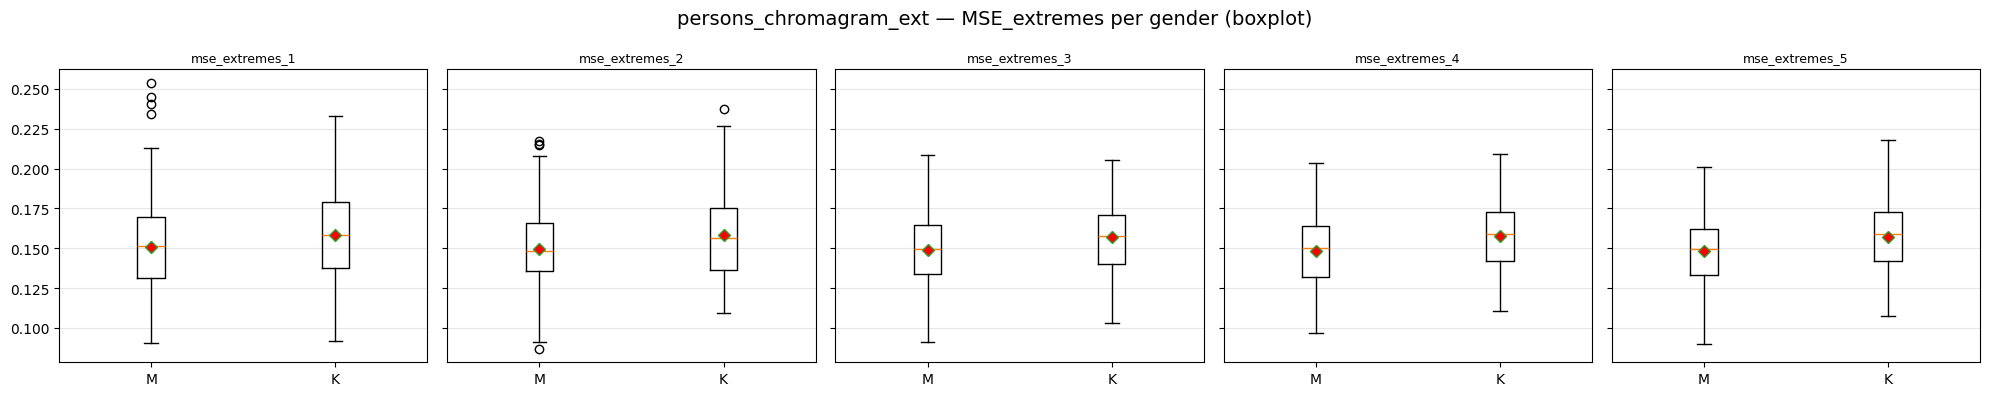

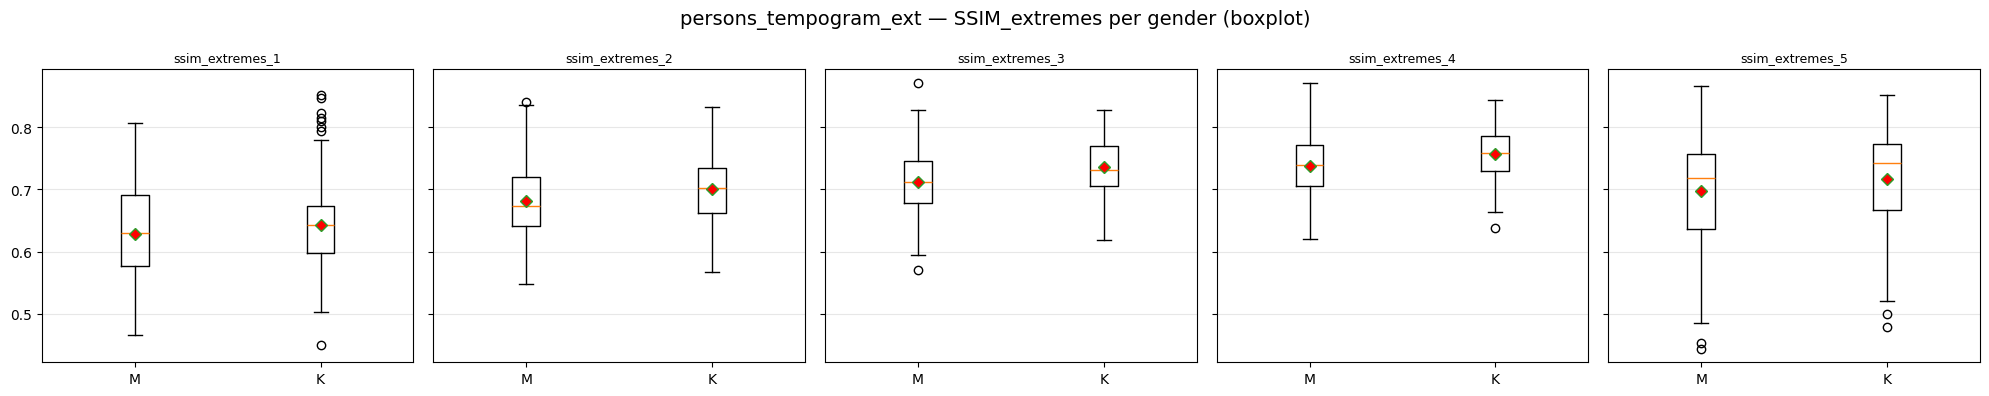

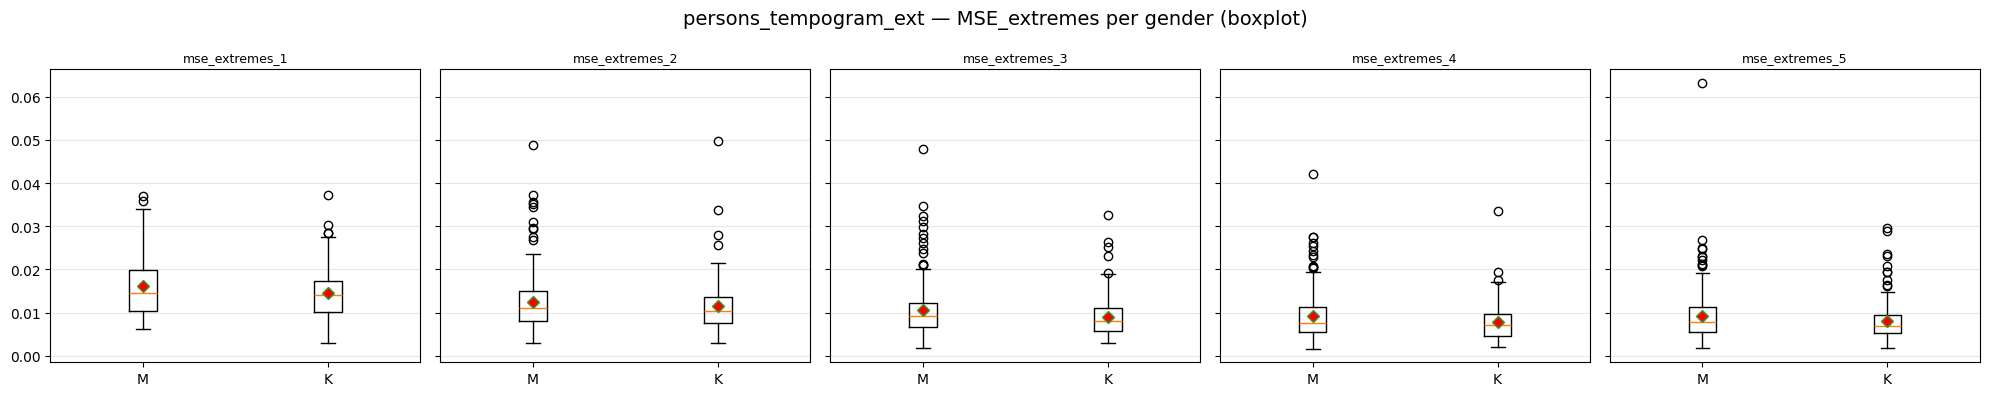

In [353]:


frames = {
  "persons_linear_ext":              persons_linear_ext,
  "persons_cqt_ext":                 persons_cqt_ext,
  "persons_chromagram_ext":          persons_chromagram_ext,
  "persons_tempogram_ext":           persons_tempogram_ext,   # ← fixed
}

for name, frame in frames.items():
  get_image_extremes(frame, name, "ssim")
  get_image_extremes(frame, name, "mse") 
for name, frame in frames.items():
  get_image_box_extremes(frame, name, "ssim") 
  get_image_box_extremes(frame, name, "mse") 

In [292]:
persons_linear_ext.columns

Index(['VoxCeleb_ID', 'video_id', 'gender', 'speaker_age', 'wav_path',
       'age_vid_id', 'age_youngest_1', 'age_oldest_1', 'age_range_1',
       'n_recordings_1', 'ssim_extremes_1', 'mse_extremes_1', 'age_youngest_2',
       'age_oldest_2', 'age_range_2', 'n_recordings_2', 'ssim_extremes_2',
       'mse_extremes_2', 'age_youngest_3', 'age_oldest_3', 'age_range_3',
       'n_recordings_3', 'ssim_extremes_3', 'mse_extremes_3', 'age_youngest_4',
       'age_oldest_4', 'age_range_4', 'n_recordings_4', 'ssim_extremes_4',
       'mse_extremes_4', 'age_youngest_5', 'age_oldest_5', 'age_range_5',
       'n_recordings_5', 'ssim_extremes_5', 'mse_extremes_5'],
      dtype='object')

In [293]:
corr_col=['VoxCeleb_ID', 'video_id', 'gender', 'speaker_age', 'wav_path',
        'ssim_extremes_1', 'mse_extremes_1', 'ssim_extremes_2',
       'mse_extremes_2', 'ssim_extremes_3', 'mse_extremes_3', 'ssim_extremes_4',
       'mse_extremes_4', 'ssim_extremes_5', 'mse_extremes_5']
persons_linear_ext[persons_linear_ext.gender=="female"][corr_col].describe()

,speaker_age,ssim_extremes_1,mse_extremes_1,ssim_extremes_2,mse_extremes_2,ssim_extremes_3,mse_extremes_3,ssim_extremes_4,mse_extremes_4,ssim_extremes_5,mse_extremes_5
count,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000
mean,36.007299,0.092482,286.576536,0.095573,272.487156,0.095963,270.045063,0.096794,268.624696,0.097340,269.012973
std,12.926544,0.021297,108.137143,0.018049,91.181323,0.017020,79.597956,0.016706,78.118200,0.016676,77.739615
min,12.000000,0.041146,160.679991,0.062313,172.427847,0.058089,168.073800,0.064089,155.023169,0.066210,152.685116
25%,27.000000,0.080563,227.631951,0.086120,223.454939,0.086438,224.572068,0.086604,227.284854,0.088554,226.265173
50%,32.000000,0.088619,257.402820,0.092445,248.515799,0.094181,246.717290,0.093635,252.716585,0.094776,252.511384
75%,44.000000,0.101166,312.713412,0.102872,288.639441,0.101014,294.993701,0.101715,283.933689,0.101746,283.790587
max,80.000000,0.234266,787.542770,0.195842,830.114001,0.194616,764.951997,0.170185,770.556028,0.172827,770.561878


In [294]:
persons_linear_ext[persons_linear_ext.gender=="male"][corr_col].describe()

,speaker_age,ssim_extremes_1,mse_extremes_1,ssim_extremes_2,mse_extremes_2,ssim_extremes_3,mse_extremes_3,ssim_extremes_4,mse_extremes_4,ssim_extremes_5,mse_extremes_5
count,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000
mean,44.030457,0.097453,291.833628,0.100668,284.417318,0.102787,281.474531,0.103913,277.965520,0.104637,276.519765
std,14.641606,0.027913,109.770575,0.025594,88.864840,0.025261,77.802788,0.025280,74.708977,0.024725,72.418100
min,18.000000,0.043925,142.292380,0.044499,135.996326,0.068579,145.252254,0.063325,146.580291,0.067264,157.326837
25%,31.000000,0.082156,221.785055,0.085972,221.324333,0.088341,225.473524,0.089394,230.004428,0.092177,230.619158
50%,43.000000,0.096098,269.092738,0.096502,272.447164,0.099521,267.043333,0.099952,264.591799,0.100195,261.935596
75%,54.000000,0.108678,336.015951,0.110966,324.439565,0.113133,320.030162,0.112066,312.518449,0.111884,316.227904
max,78.000000,0.294762,1043.030345,0.330183,791.095707,0.341286,736.066101,0.349486,666.712079,0.345592,645.245220


In [295]:
persons_log_freq_power_spec_ext[persons_log_freq_power_spec_ext.gender=="female"][corr_col].describe()

,speaker_age,ssim_extremes_1,mse_extremes_1,ssim_extremes_2,mse_extremes_2,ssim_extremes_3,mse_extremes_3,ssim_extremes_4,mse_extremes_4,ssim_extremes_5,mse_extremes_5
count,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000
mean,36.007299,0.092482,286.576536,0.095573,272.487156,0.095963,270.045063,0.096794,268.624696,0.097340,269.012973
std,12.926544,0.021297,108.137143,0.018049,91.181323,0.017020,79.597956,0.016706,78.118200,0.016676,77.739615
min,12.000000,0.041146,160.679991,0.062313,172.427847,0.058089,168.073800,0.064089,155.023169,0.066210,152.685116
25%,27.000000,0.080563,227.631951,0.086120,223.454939,0.086438,224.572068,0.086604,227.284854,0.088554,226.265173
50%,32.000000,0.088619,257.402820,0.092445,248.515799,0.094181,246.717290,0.093635,252.716585,0.094776,252.511384
75%,44.000000,0.101166,312.713412,0.102872,288.639441,0.101014,294.993701,0.101715,283.933689,0.101746,283.790587
max,80.000000,0.234266,787.542770,0.195842,830.114001,0.194616,764.951997,0.170185,770.556028,0.172827,770.561878


In [296]:
persons_log_freq_power_spec_ext[persons_log_freq_power_spec_ext.gender=="male"][corr_col].describe()

,speaker_age,ssim_extremes_1,mse_extremes_1,ssim_extremes_2,mse_extremes_2,ssim_extremes_3,mse_extremes_3,ssim_extremes_4,mse_extremes_4,ssim_extremes_5,mse_extremes_5
count,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000
mean,44.030457,0.097453,291.833628,0.100668,284.417318,0.102787,281.474531,0.103913,277.965520,0.104637,276.519765
std,14.641606,0.027913,109.770575,0.025594,88.864840,0.025261,77.802788,0.025280,74.708977,0.024725,72.418100
min,18.000000,0.043925,142.292380,0.044499,135.996326,0.068579,145.252254,0.063325,146.580291,0.067264,157.326837
25%,31.000000,0.082156,221.785055,0.085972,221.324333,0.088341,225.473524,0.089394,230.004428,0.092177,230.619158
50%,43.000000,0.096098,269.092738,0.096502,272.447164,0.099521,267.043333,0.099952,264.591799,0.100195,261.935596
75%,54.000000,0.108678,336.015951,0.110966,324.439565,0.113133,320.030162,0.112066,312.518449,0.111884,316.227904
max,78.000000,0.294762,1043.030345,0.330183,791.095707,0.341286,736.066101,0.349486,666.712079,0.345592,645.245220


In [297]:
persons_cqt_ext[persons_cqt_ext.gender=="female"][corr_col].describe()

,speaker_age,ssim_extremes_1,mse_extremes_1,ssim_extremes_2,mse_extremes_2,ssim_extremes_3,mse_extremes_3,ssim_extremes_4,mse_extremes_4,ssim_extremes_5,mse_extremes_5
count,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000
mean,36.007299,0.076897,309.419670,0.079490,301.020721,0.082515,298.948293,0.081254,300.610298,0.080915,304.014644
std,12.926544,0.034369,117.130124,0.030298,111.509409,0.029054,97.869011,0.027832,96.948756,0.027134,96.575127
min,12.000000,-0.001955,134.291172,0.020930,137.373755,0.025326,134.475636,0.023628,138.735548,0.022204,144.079387
25%,27.000000,0.056800,240.383206,0.060296,237.365006,0.062411,240.735300,0.062036,233.085241,0.059679,237.456324
50%,32.000000,0.074357,277.642321,0.074834,272.099623,0.078484,271.637731,0.078382,279.197515,0.077897,282.726418
75%,44.000000,0.096698,344.614477,0.100954,332.470529,0.102641,331.868485,0.097194,341.117823,0.096366,342.544591
max,80.000000,0.190881,886.907390,0.168425,919.914836,0.171978,712.116457,0.160717,739.166476,0.159151,767.036938


In [298]:
persons_cqt_ext[persons_cqt_ext.gender=="male"][corr_col].describe()

,speaker_age,ssim_extremes_1,mse_extremes_1,ssim_extremes_2,mse_extremes_2,ssim_extremes_3,mse_extremes_3,ssim_extremes_4,mse_extremes_4,ssim_extremes_5,mse_extremes_5
count,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000
mean,44.030457,0.087194,315.912755,0.089516,314.562486,0.090856,312.031430,0.091686,311.226894,0.091375,315.139348
std,14.641606,0.039071,112.743757,0.032257,99.426377,0.030815,96.580355,0.029524,94.673449,0.028630,96.074550
min,18.000000,-0.000285,138.307618,0.007496,143.623253,0.019257,156.383164,0.024314,158.111884,0.025053,163.431167
25%,31.000000,0.061197,240.542555,0.067096,242.988084,0.072188,246.745130,0.071323,243.368877,0.072180,247.939670
50%,43.000000,0.085994,290.774703,0.087748,298.537857,0.088593,292.116820,0.089713,293.737578,0.090691,295.248708
75%,54.000000,0.111938,357.941508,0.111187,364.015206,0.106037,357.273399,0.106986,354.349514,0.106774,362.150023
max,78.000000,0.225704,837.592682,0.176158,844.375870,0.208343,786.095239,0.206936,711.564774,0.209942,706.508753


In [299]:
persons_chromagram_ext[persons_chromagram_ext.gender=="female"][corr_col].describe()

,speaker_age,ssim_extremes_1,mse_extremes_1,ssim_extremes_2,mse_extremes_2,ssim_extremes_3,mse_extremes_3,ssim_extremes_4,mse_extremes_4,ssim_extremes_5,mse_extremes_5
count,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000
mean,36.007299,0.005965,0.158450,0.015034,0.158416,0.020961,0.157217,0.020714,0.157503,0.017702,0.157308
std,12.926544,0.102272,0.030380,0.082272,0.026052,0.070998,0.022645,0.063964,0.021948,0.059781,0.021378
min,12.000000,-0.272015,0.091652,-0.198754,0.109392,-0.134203,0.103057,-0.097428,0.110598,-0.097687,0.107472
25%,27.000000,-0.051066,0.137838,-0.037977,0.136393,-0.031600,0.140250,-0.026694,0.142124,-0.026275,0.142025
50%,32.000000,0.014234,0.158421,0.017189,0.156577,0.021852,0.157932,0.014874,0.159142,0.014017,0.159102
75%,44.000000,0.073790,0.179205,0.071398,0.175298,0.066475,0.171027,0.060810,0.172702,0.056574,0.172853
max,80.000000,0.279065,0.233034,0.223090,0.237244,0.246973,0.205348,0.240493,0.209101,0.203028,0.218098


In [300]:
persons_chromagram_ext[persons_chromagram_ext.gender=="male"][corr_col].describe()

,speaker_age,ssim_extremes_1,mse_extremes_1,ssim_extremes_2,mse_extremes_2,ssim_extremes_3,mse_extremes_3,ssim_extremes_4,mse_extremes_4,ssim_extremes_5,mse_extremes_5
count,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000
mean,44.030457,0.024633,0.151008,0.034056,0.149777,0.033580,0.148950,0.036243,0.148511,0.036131,0.148143
std,14.641606,0.111839,0.030369,0.094455,0.024932,0.086798,0.022994,0.079131,0.022156,0.079523,0.021589
min,18.000000,-0.273202,0.090602,-0.212569,0.086793,-0.185454,0.091234,-0.155887,0.097023,-0.167038,0.089899
25%,31.000000,-0.060165,0.131035,-0.019557,0.135440,-0.016831,0.133713,-0.015870,0.132097,-0.013925,0.133032
50%,43.000000,0.016136,0.151387,0.028809,0.148470,0.026367,0.149817,0.031428,0.150182,0.027724,0.149412
75%,54.000000,0.096519,0.169866,0.079917,0.165613,0.076588,0.164371,0.074692,0.164136,0.077015,0.162352
max,78.000000,0.305377,0.253882,0.405664,0.217524,0.385076,0.208582,0.314490,0.203725,0.338172,0.201221


In [301]:
persons_tempogram_ext[persons_tempogram_ext.gender=="female"][corr_col].describe()

,speaker_age,ssim_extremes_1,mse_extremes_1,ssim_extremes_2,mse_extremes_2,ssim_extremes_3,mse_extremes_3,ssim_extremes_4,mse_extremes_4,ssim_extremes_5,mse_extremes_5
count,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000
mean,36.007299,0.643339,0.014507,0.700665,0.011438,0.735213,0.009045,0.757127,0.007795,0.716628,0.008084
std,12.926544,0.075872,0.005915,0.054861,0.005971,0.046550,0.004739,0.042643,0.004294,0.080189,0.004765
min,12.000000,0.450968,0.002969,0.567400,0.002889,0.618320,0.003029,0.637149,0.002115,0.478272,0.001811
25%,27.000000,0.597114,0.010164,0.662147,0.007487,0.704683,0.005740,0.729923,0.004666,0.667464,0.005165
50%,32.000000,0.642673,0.014085,0.702430,0.010463,0.731027,0.007987,0.758066,0.007170,0.742767,0.007007
75%,44.000000,0.672711,0.017372,0.734315,0.013601,0.769196,0.011103,0.785298,0.009713,0.773183,0.009473
max,80.000000,0.851153,0.037209,0.832437,0.049826,0.827830,0.032612,0.844017,0.033605,0.850646,0.029558


In [302]:
persons_tempogram_ext[persons_tempogram_ext.gender=="male"][corr_col].describe()

,speaker_age,ssim_extremes_1,mse_extremes_1,ssim_extremes_2,mse_extremes_2,ssim_extremes_3,mse_extremes_3,ssim_extremes_4,mse_extremes_4,ssim_extremes_5,mse_extremes_5
count,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000
mean,44.030457,0.628479,0.016109,0.681609,0.012552,0.712395,0.010608,0.737311,0.009218,0.696609,0.009319
std,14.641606,0.076511,0.006842,0.058703,0.006709,0.052815,0.006329,0.048106,0.005591,0.083702,0.006159
min,18.000000,0.466249,0.006305,0.547817,0.002873,0.569743,0.001781,0.619624,0.001584,0.443817,0.001852
25%,31.000000,0.576809,0.010412,0.641397,0.008001,0.678022,0.006567,0.704613,0.005576,0.636530,0.005556
50%,43.000000,0.629463,0.014640,0.672576,0.011097,0.711665,0.009154,0.739317,0.007560,0.717534,0.007790
75%,54.000000,0.691508,0.019899,0.719009,0.015108,0.744835,0.012164,0.771271,0.011335,0.757056,0.011188
max,78.000000,0.807097,0.036953,0.840860,0.048768,0.871224,0.047957,0.870025,0.042031,0.866561,0.063243


### SSIM and MSE between correlation 

In [305]:
corr_col=['VoxCeleb_ID', 'video_id', 'gender', 'speaker_age', 'wav_path',
       'age_vid_id', 'pearson_ssim_r_1', 'pearson_mse_r_1',
       'pearson_ssim_r_2',
        'pearson_mse_r_2', 
        'pearson_ssim_r_3',
       'pearson_mse_r_3','pearson_ssim_r_4', 'pearson_mse_r_4',
        'pearson_ssim_r_5',
       'pearson_mse_r_5']
names = ["persons_linear", "persons_log_freq_power_spec", "persons_cqt_power_spec",
           "persons_chromagram", "persons_tempogram"]
frames = [persons_linear,persons_log_freq_power_spec,persons_cqt_power_spec,persons_chromagram,persons_tempogram]

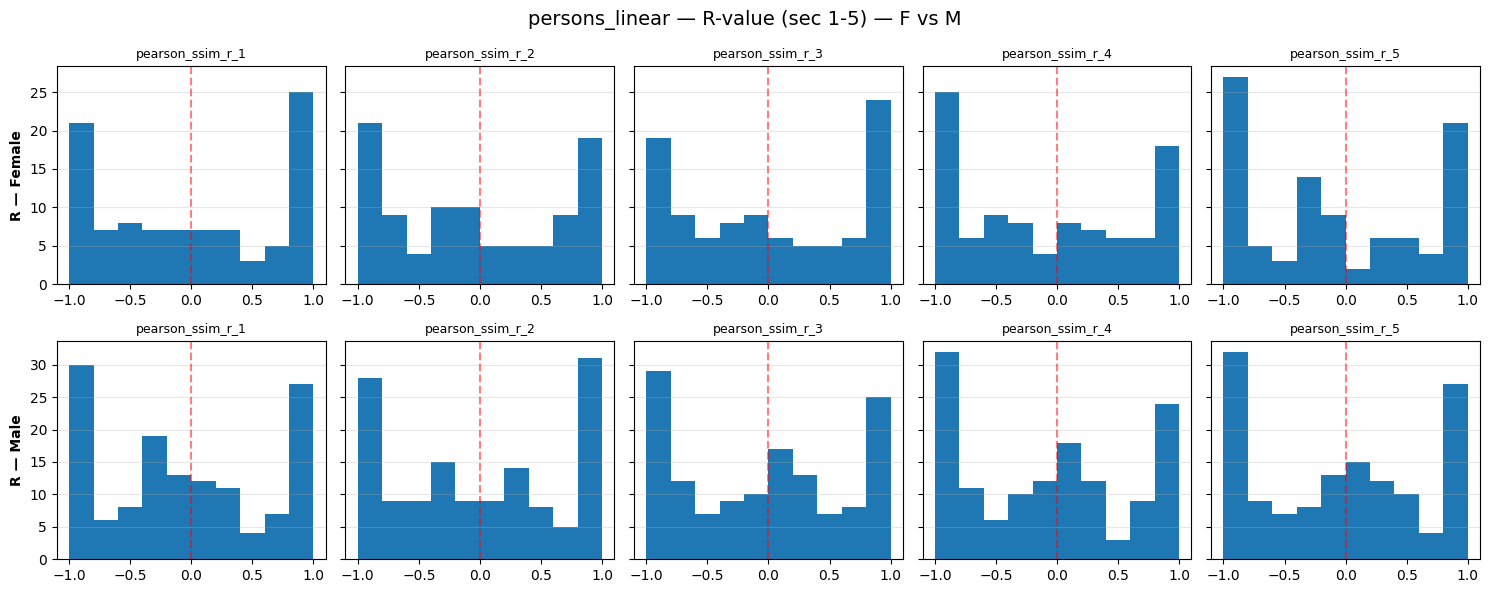

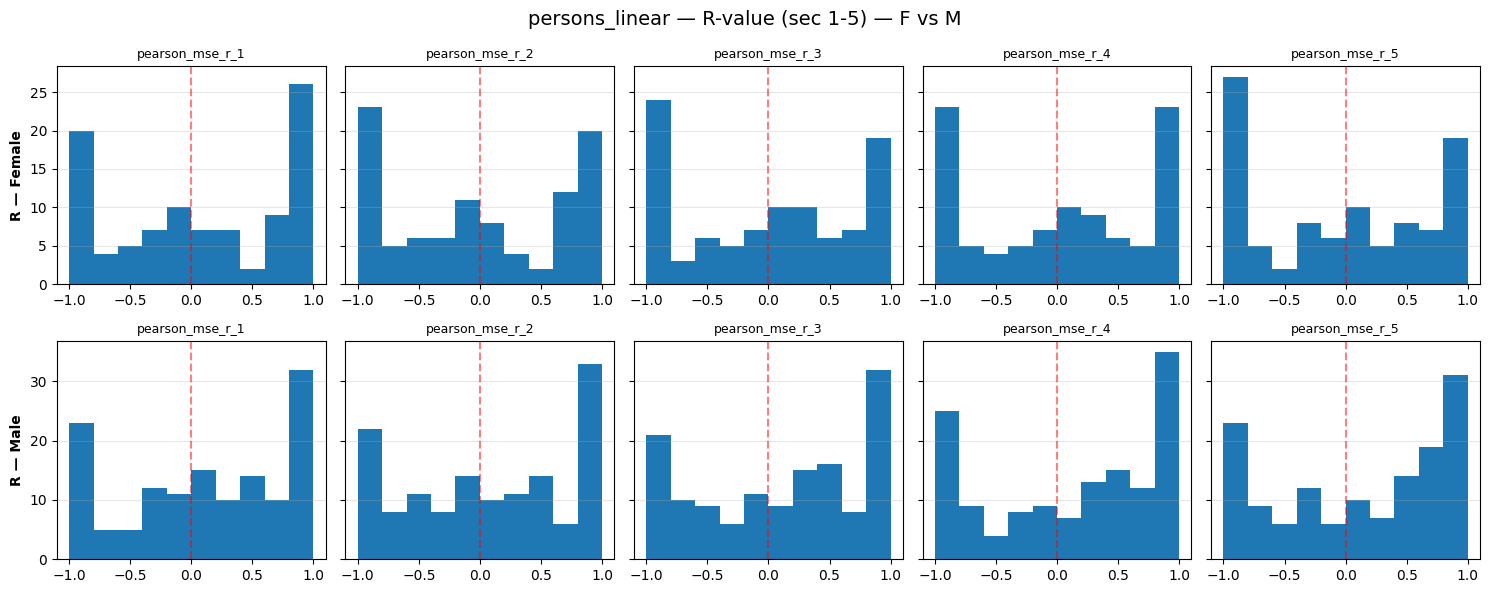

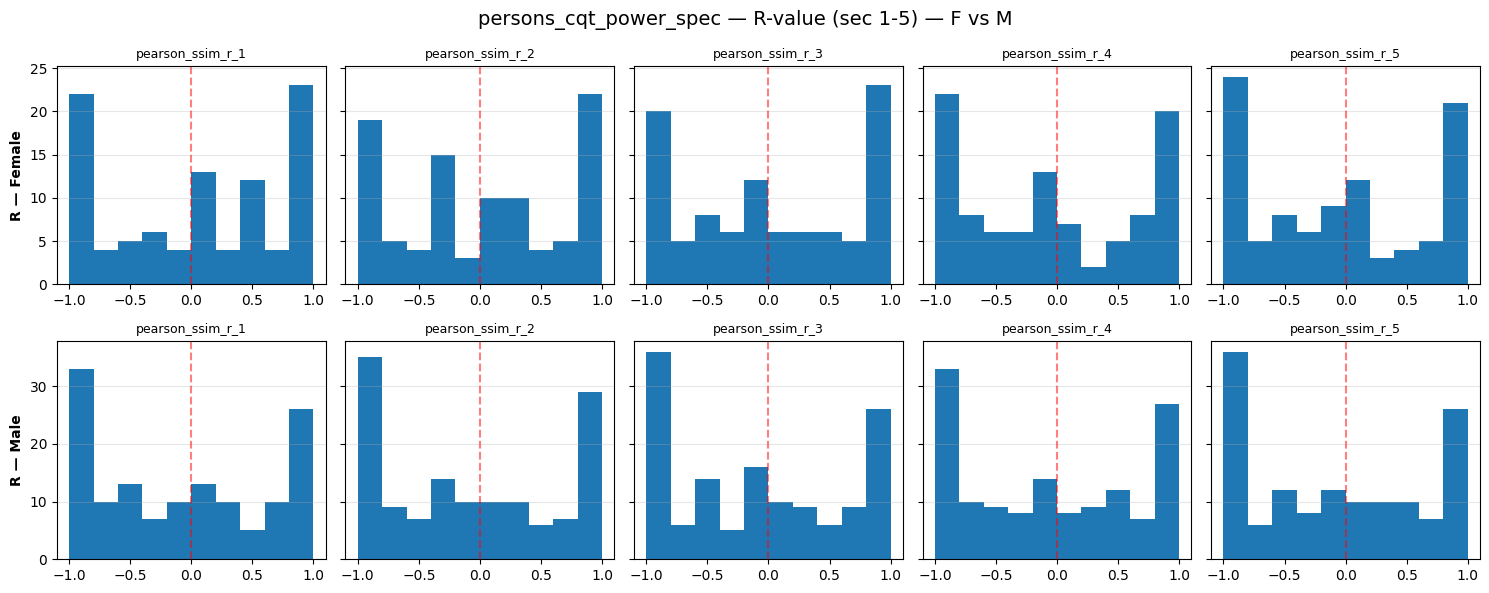

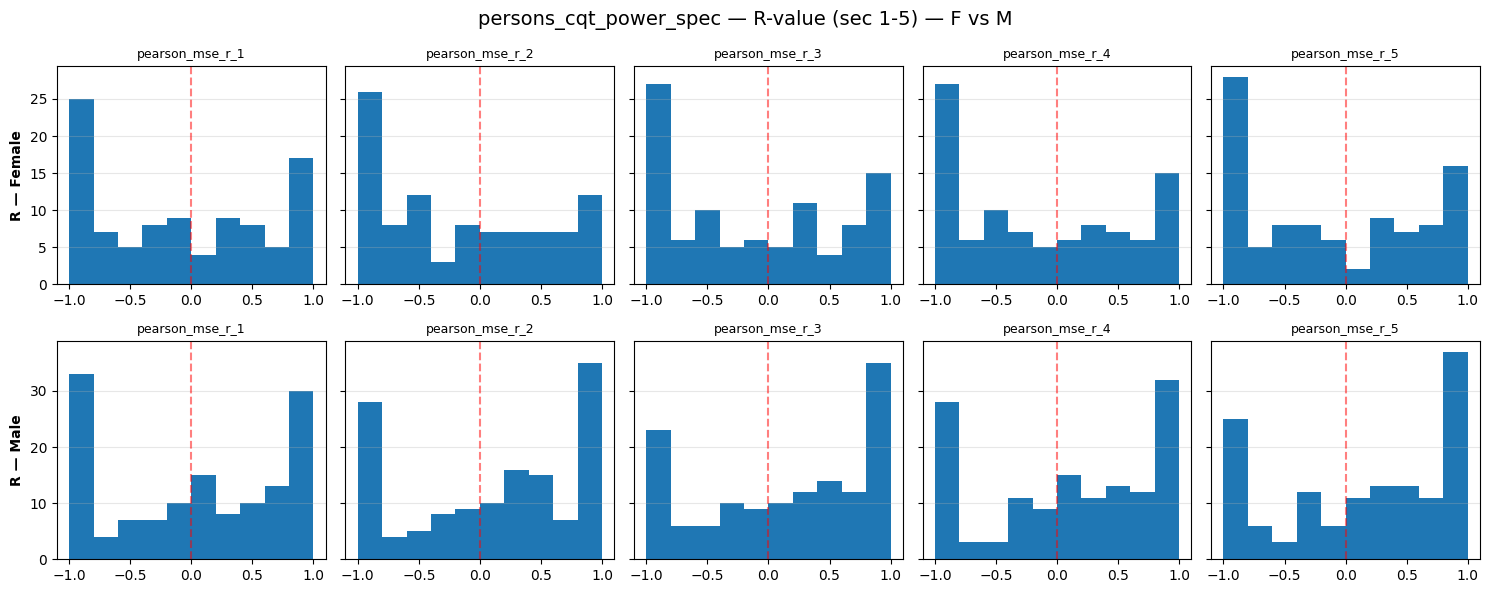

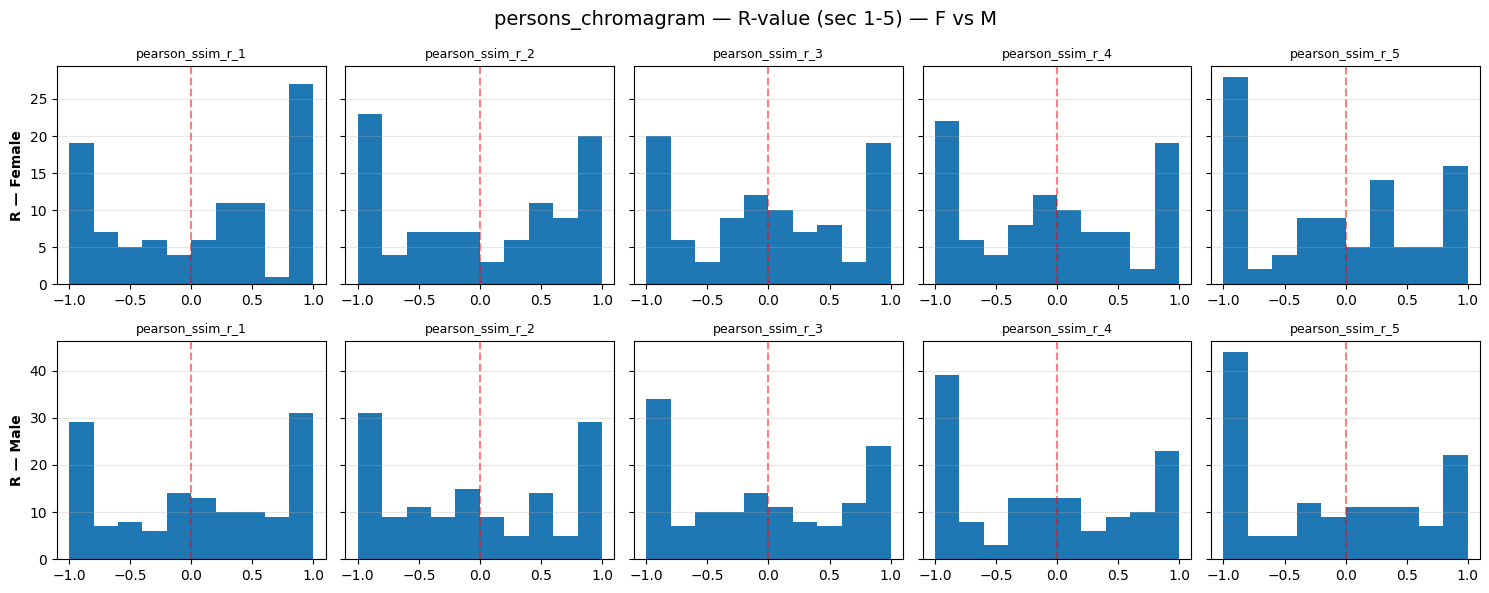

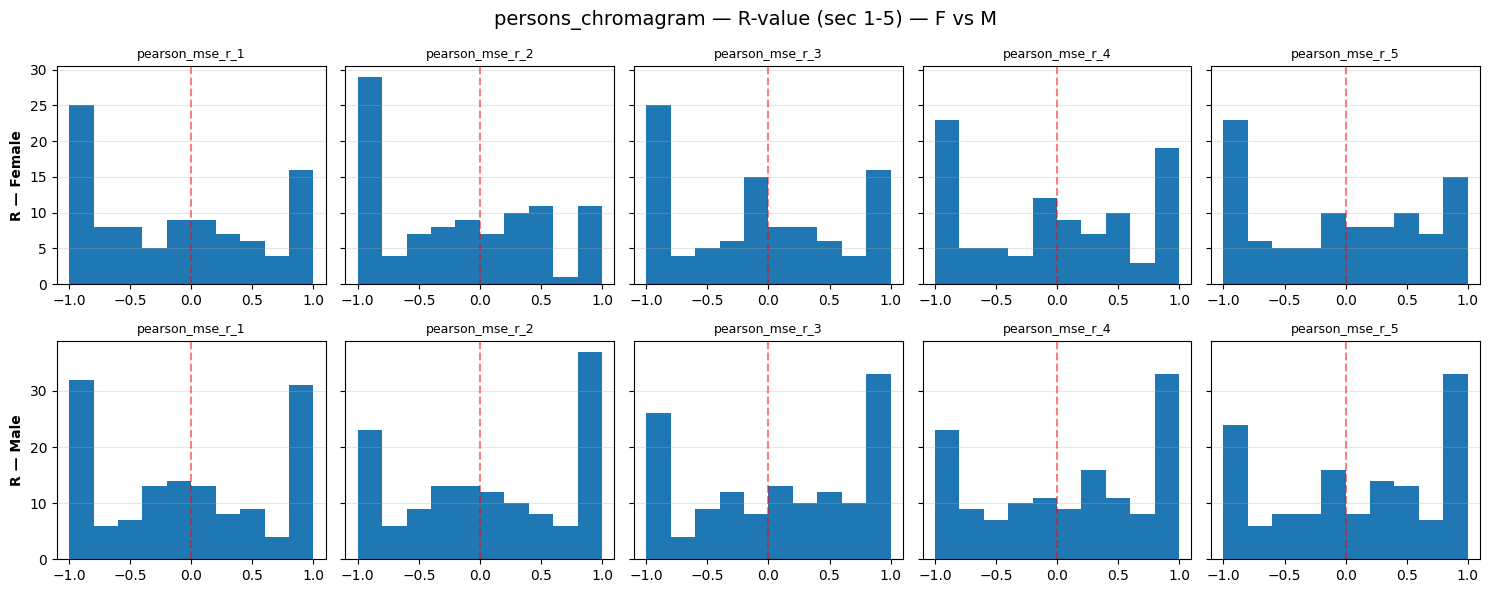

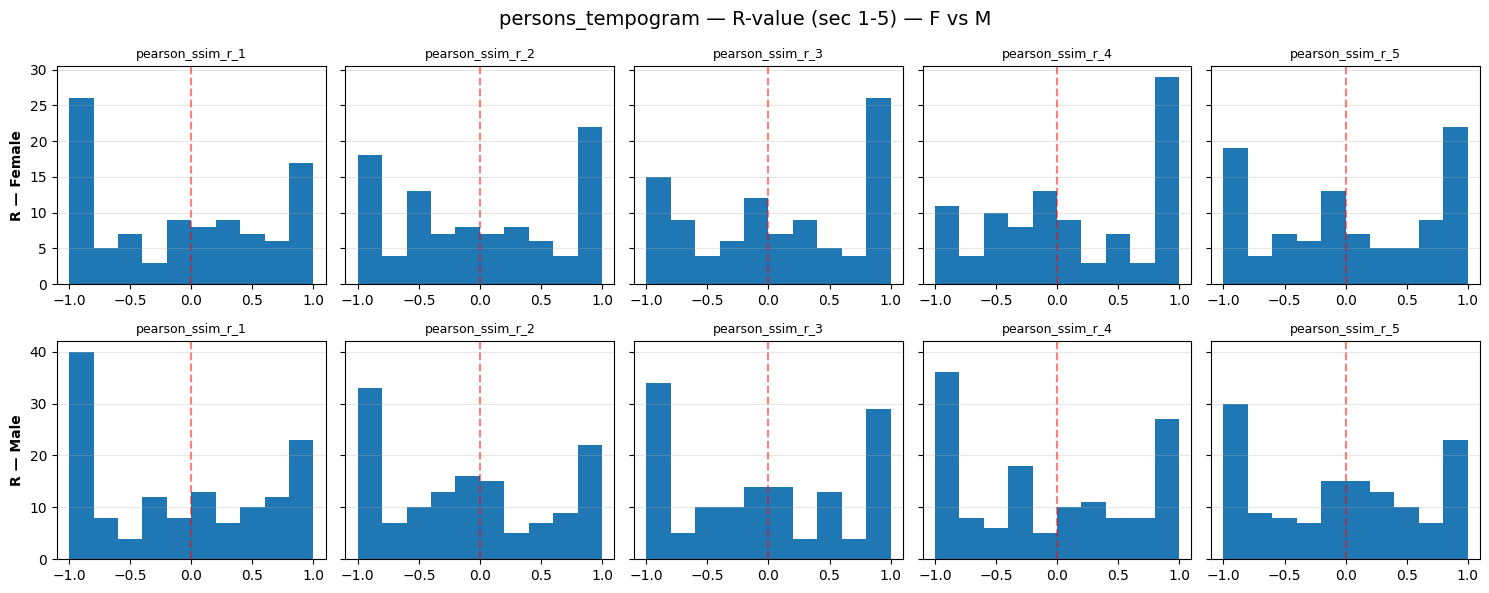

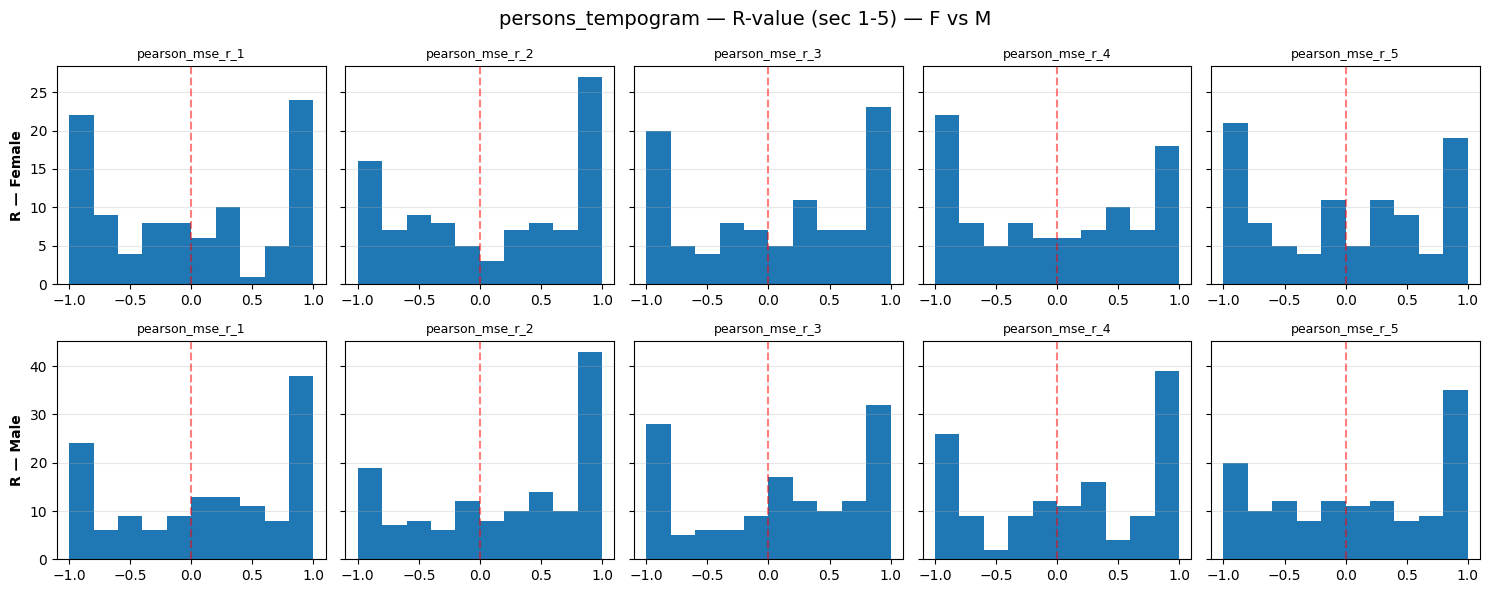

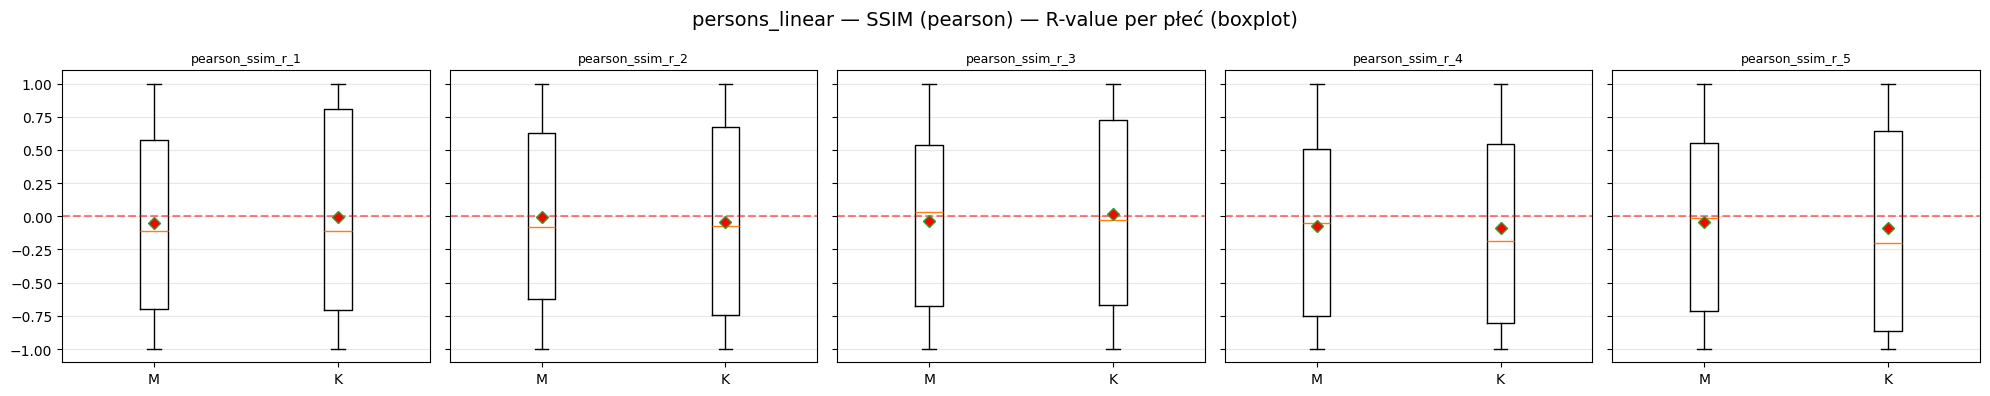

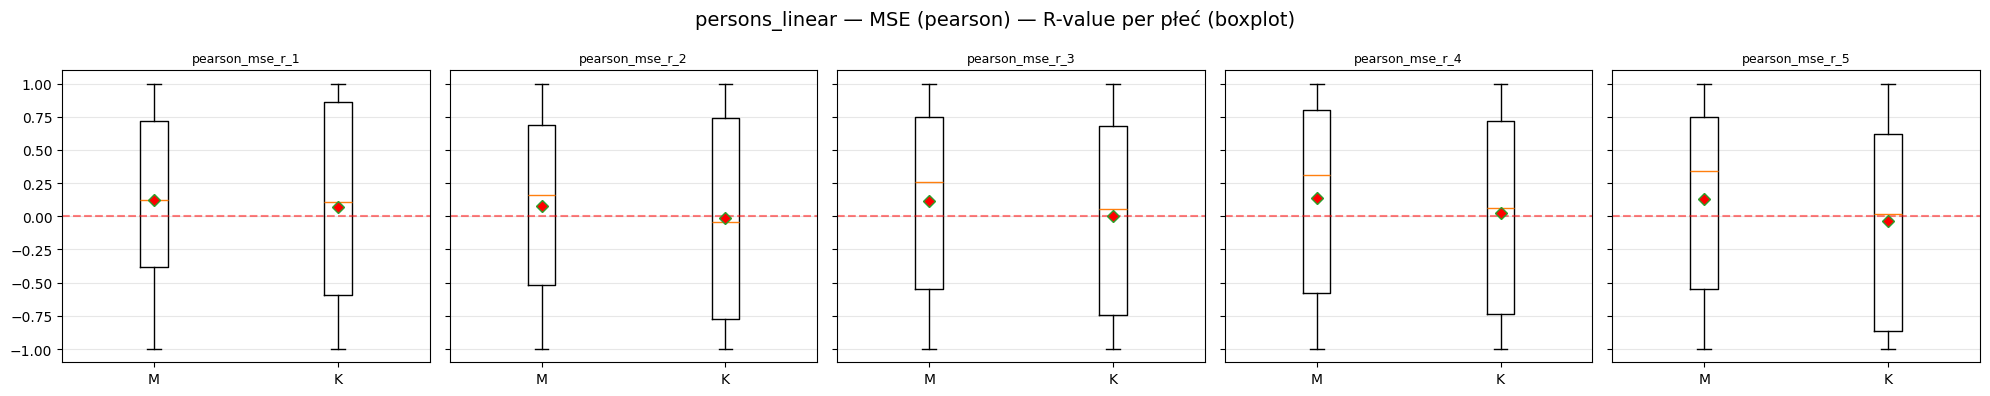

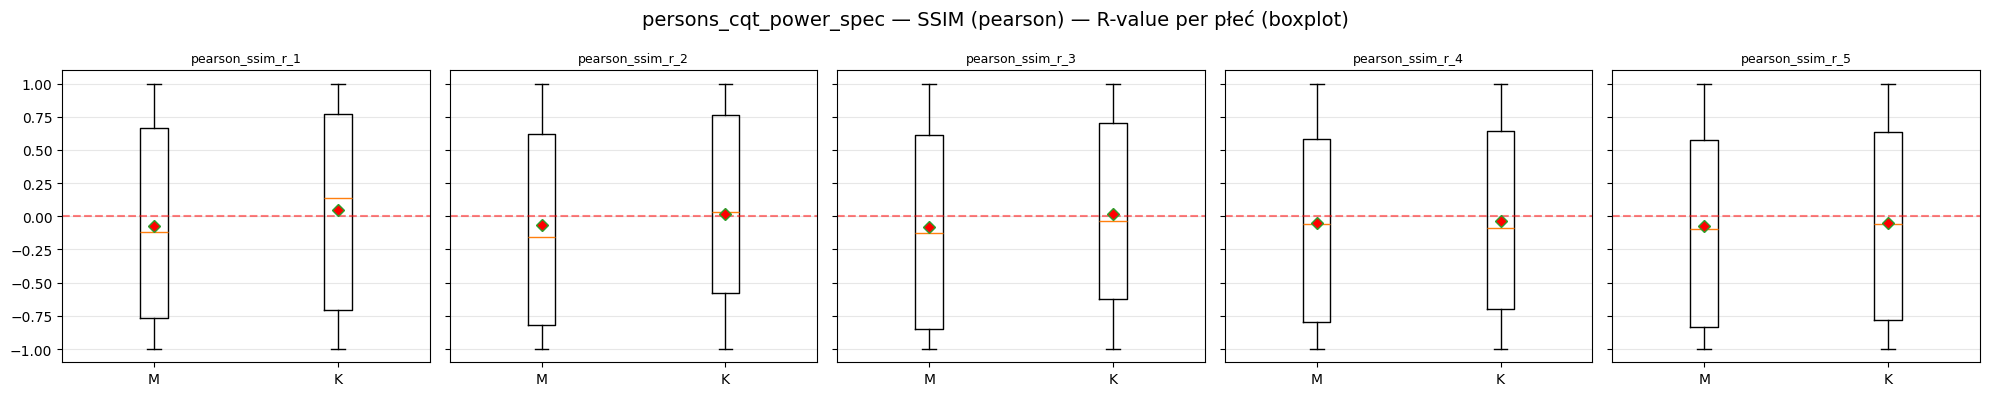

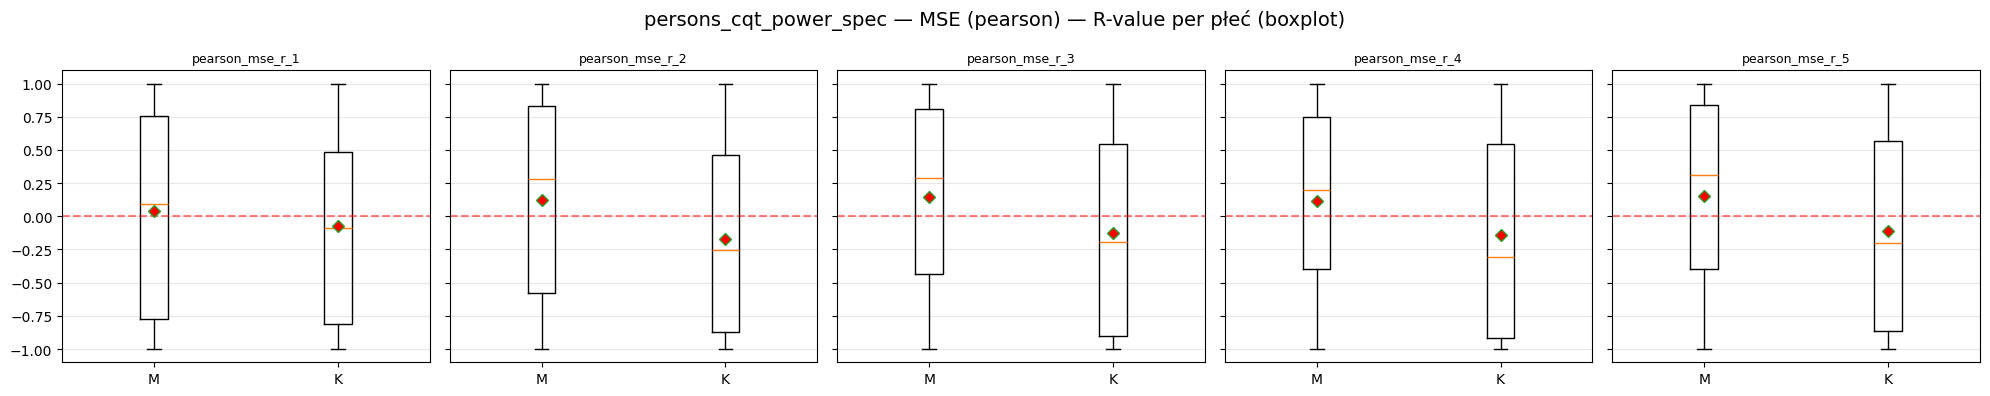

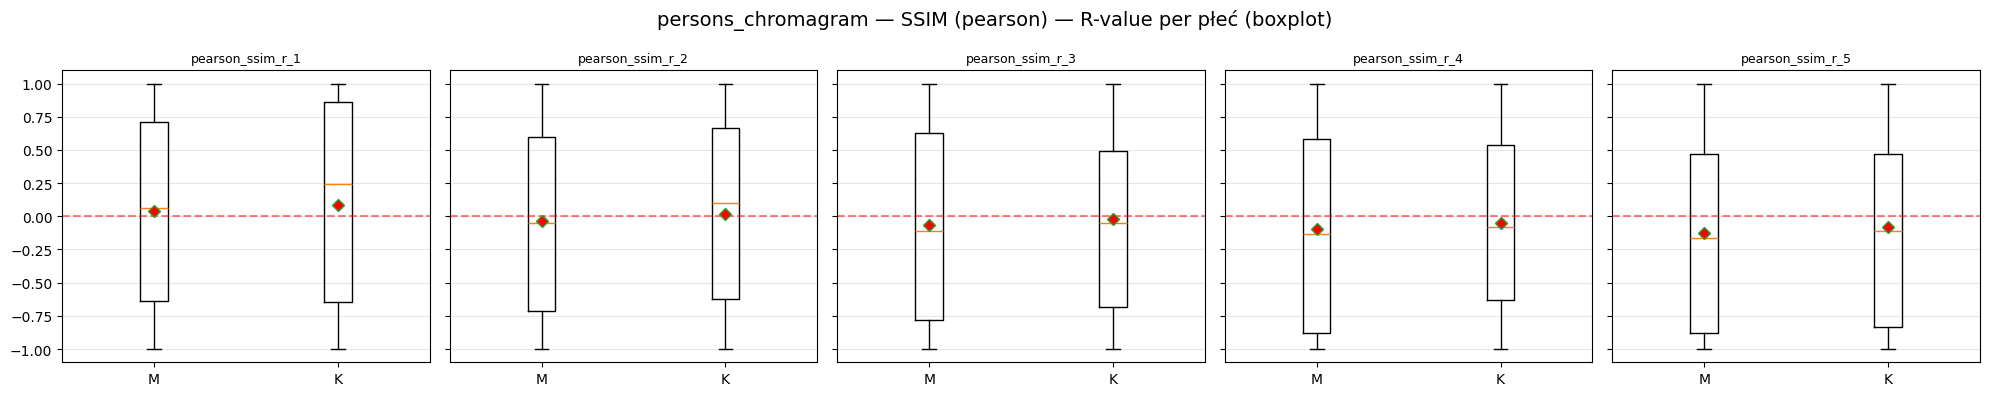

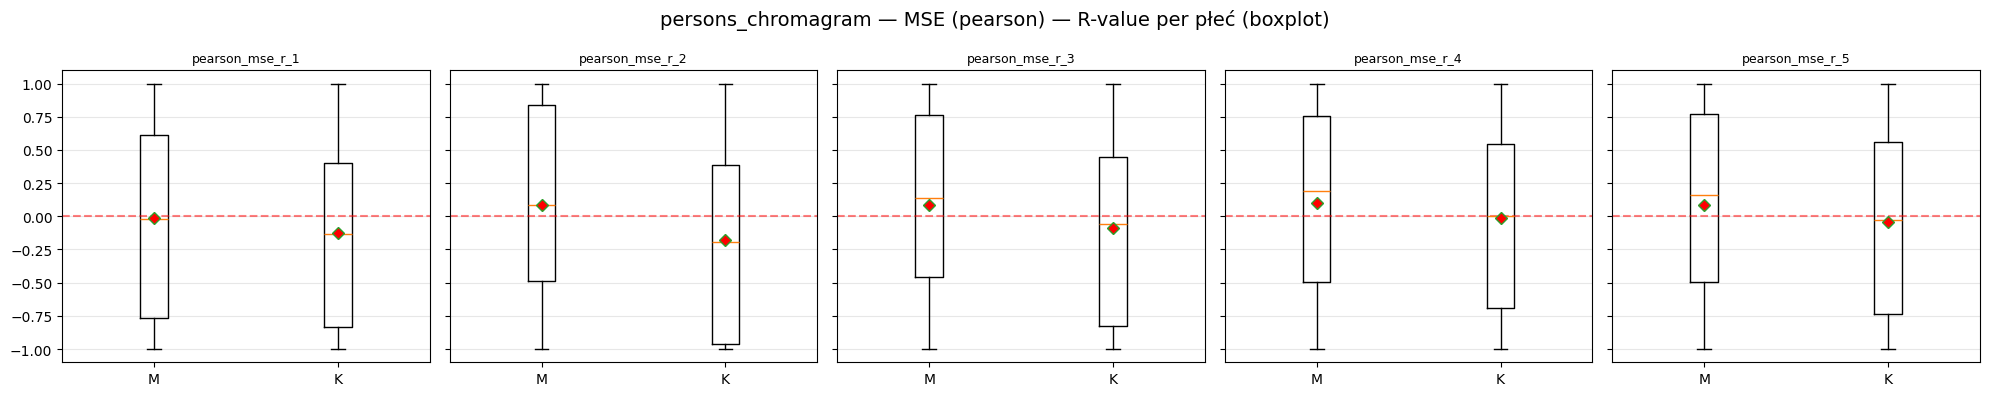

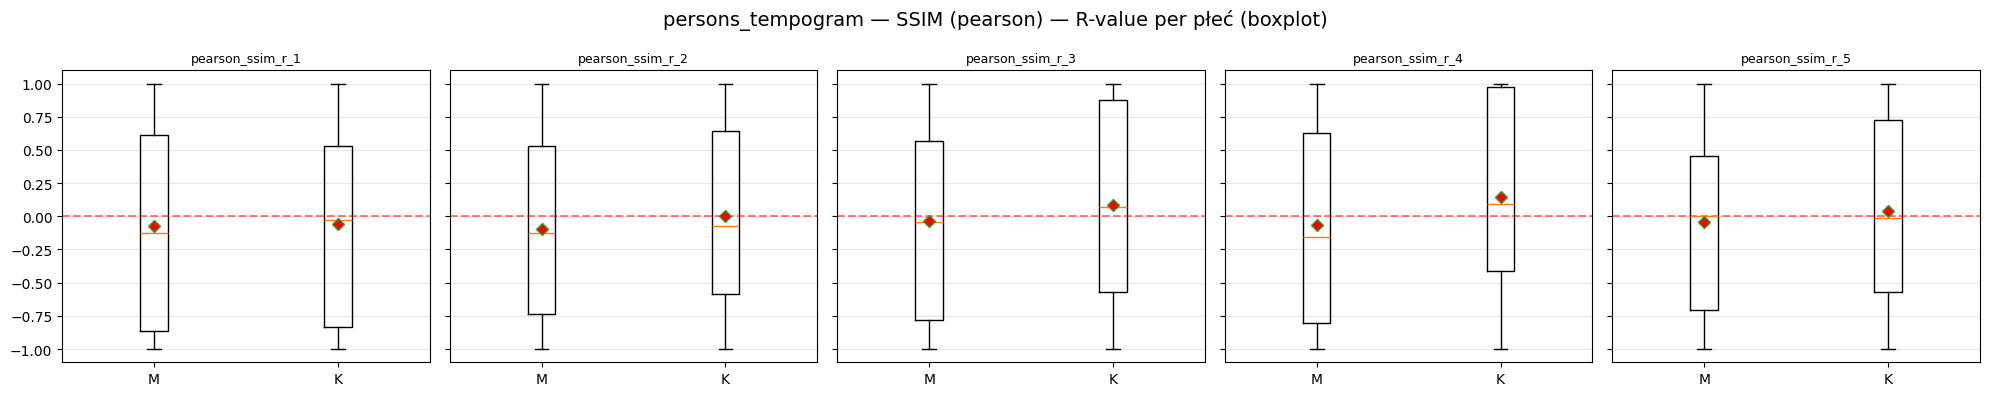

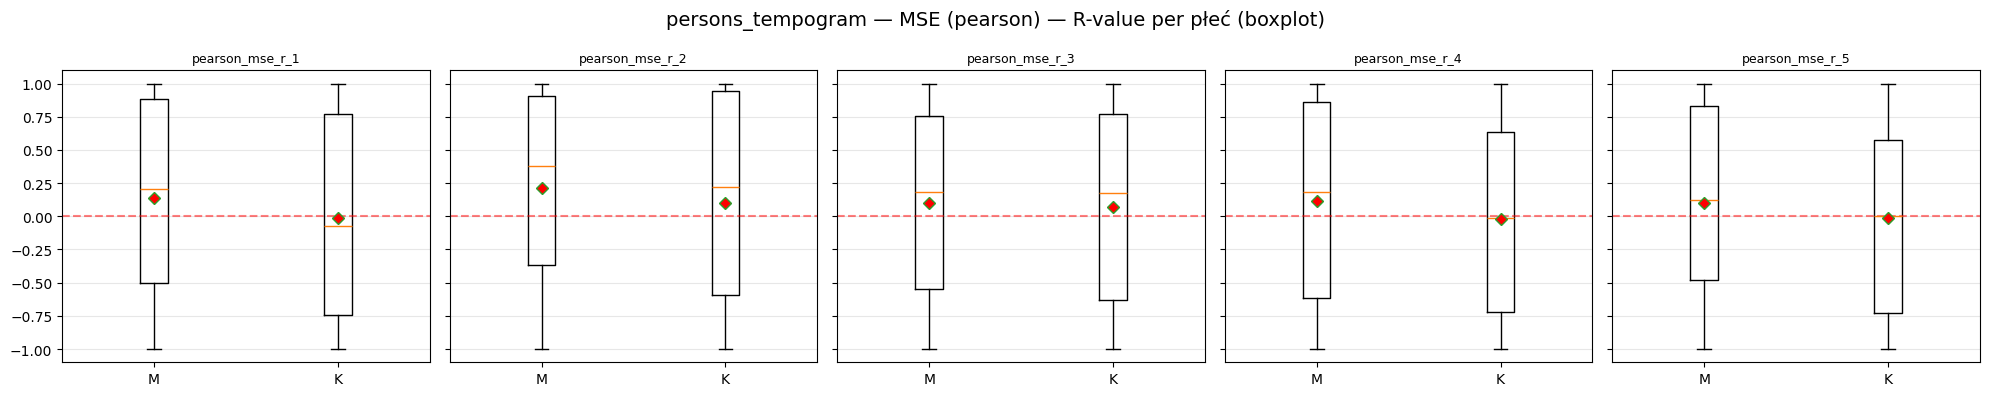

In [354]:
frames = {
  "persons_linear":              persons_linear,
  "persons_cqt_power_spec":                 persons_cqt_power_spec,
  "persons_chromagram":          persons_chromagram,
  "persons_tempogram":           persons_tempogram,   # ← fixed
}

for name, frame in frames.items():
  get_image(frame, name, "ssim")   
  get_image(frame, name, "mse")
for name, frame in frames.items():
  get_image_box(frame, name, "ssim")   
  get_image_box(frame, name, "mse")


In [259]:
persons_linear[persons_linear.gender=="female"][corr_col].describe()

,speaker_age,pearson_ssim_r_1,pearson_mse_r_1,pearson_ssim_r_2,pearson_mse_r_2,pearson_ssim_r_3,pearson_mse_r_3,pearson_ssim_r_4,pearson_mse_r_4,pearson_ssim_r_5,pearson_mse_r_5
count,137.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000
mean,36.007299,-0.002897,0.068604,-0.040840,-0.011826,0.016828,-0.000919,-0.085697,0.023709,-0.090044,-0.037370
std,12.926544,0.750235,0.749800,0.727363,0.734695,0.733913,0.723638,0.730953,0.736663,0.739396,0.742182
min,12.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,27.000000,-0.708452,-0.593714,-0.745451,-0.770118,-0.668211,-0.746338,-0.805431,-0.739725,-0.863964,-0.863764
50%,32.000000,-0.107461,0.107393,-0.074170,-0.041816,-0.029988,0.053001,-0.186621,0.058996,-0.204801,0.020432
75%,44.000000,0.808944,0.859405,0.669223,0.739835,0.725253,0.680145,0.542374,0.715378,0.642003,0.622603
max,80.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [260]:
persons_linear[persons_linear.gender=="male"][corr_col].describe()

,speaker_age,pearson_ssim_r_1,pearson_mse_r_1,pearson_ssim_r_2,pearson_mse_r_2,pearson_ssim_r_3,pearson_mse_r_3,pearson_ssim_r_4,pearson_mse_r_4,pearson_ssim_r_5,pearson_mse_r_5
count,197.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000
mean,44.030457,-0.052829,0.119134,-0.005960,0.079265,-0.038022,0.111774,-0.070008,0.139450,-0.043788,0.130477
std,14.641606,0.691395,0.688746,0.715340,0.696934,0.698734,0.698094,0.699240,0.723006,0.707154,0.713031
min,18.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,31.000000,-0.696573,-0.380807,-0.625009,-0.519818,-0.676298,-0.544090,-0.751196,-0.580049,-0.717308,-0.550785
50%,43.000000,-0.109151,0.126336,-0.084009,0.158873,0.032135,0.259115,-0.047330,0.312245,-0.016416,0.340176
75%,54.000000,0.577153,0.721645,0.625729,0.688291,0.537044,0.747916,0.504743,0.800314,0.551923,0.749927
max,78.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [261]:
persons_log_freq_power_spec[persons_log_freq_power_spec.gender=="female"][corr_col].describe()

,speaker_age,pearson_ssim_r_1,pearson_mse_r_1,pearson_ssim_r_2,pearson_mse_r_2,pearson_ssim_r_3,pearson_mse_r_3,pearson_ssim_r_4,pearson_mse_r_4,pearson_ssim_r_5,pearson_mse_r_5
count,137.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000
mean,36.007299,-0.002897,0.068604,-0.040840,-0.011826,0.016828,-0.000919,-0.085697,0.023709,-0.090044,-0.037370
std,12.926544,0.750235,0.749800,0.727363,0.734695,0.733913,0.723638,0.730953,0.736663,0.739396,0.742182
min,12.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,27.000000,-0.708452,-0.593714,-0.745451,-0.770118,-0.668211,-0.746338,-0.805431,-0.739725,-0.863964,-0.863764
50%,32.000000,-0.107461,0.107393,-0.074170,-0.041816,-0.029988,0.053001,-0.186621,0.058996,-0.204801,0.020432
75%,44.000000,0.808944,0.859405,0.669223,0.739835,0.725253,0.680145,0.542374,0.715378,0.642003,0.622603
max,80.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [262]:
persons_log_freq_power_spec[persons_log_freq_power_spec.gender=="male"][corr_col].describe()

,speaker_age,pearson_ssim_r_1,pearson_mse_r_1,pearson_ssim_r_2,pearson_mse_r_2,pearson_ssim_r_3,pearson_mse_r_3,pearson_ssim_r_4,pearson_mse_r_4,pearson_ssim_r_5,pearson_mse_r_5
count,197.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000
mean,44.030457,-0.052829,0.119134,-0.005960,0.079265,-0.038022,0.111774,-0.070008,0.139450,-0.043788,0.130477
std,14.641606,0.691395,0.688746,0.715340,0.696934,0.698734,0.698094,0.699240,0.723006,0.707154,0.713031
min,18.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,31.000000,-0.696573,-0.380807,-0.625009,-0.519818,-0.676298,-0.544090,-0.751196,-0.580049,-0.717308,-0.550785
50%,43.000000,-0.109151,0.126336,-0.084009,0.158873,0.032135,0.259115,-0.047330,0.312245,-0.016416,0.340176
75%,54.000000,0.577153,0.721645,0.625729,0.688291,0.537044,0.747916,0.504743,0.800314,0.551923,0.749927
max,78.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [263]:
persons_cqt_power_spec[persons_cqt_power_spec.gender=="female"][corr_col].describe()

,speaker_age,pearson_ssim_r_1,pearson_mse_r_1,pearson_ssim_r_2,pearson_mse_r_2,pearson_ssim_r_3,pearson_mse_r_3,pearson_ssim_r_4,pearson_mse_r_4,pearson_ssim_r_5,pearson_mse_r_5
count,137.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000
mean,36.007299,0.048821,-0.074099,0.019846,-0.167869,0.017371,-0.122875,-0.034066,-0.138968,-0.048365,-0.110828
std,12.926544,0.733394,0.721265,0.719208,0.699989,0.727320,0.728288,0.728139,0.723968,0.731487,0.731544
min,12.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,27.000000,-0.704351,-0.807924,-0.575229,-0.874759,-0.621822,-0.898634,-0.699813,-0.918657,-0.782707,-0.861166
50%,32.000000,0.140056,-0.090194,0.028933,-0.256262,-0.034508,-0.193185,-0.090168,-0.304881,-0.060870,-0.201238
75%,44.000000,0.770151,0.485409,0.760936,0.460368,0.701714,0.541926,0.642961,0.543714,0.639038,0.568136
max,80.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [264]:
persons_cqt_power_spec[persons_cqt_power_spec.gender=="male"][corr_col].describe()

,speaker_age,pearson_ssim_r_1,pearson_mse_r_1,pearson_ssim_r_2,pearson_mse_r_2,pearson_ssim_r_3,pearson_mse_r_3,pearson_ssim_r_4,pearson_mse_r_4,pearson_ssim_r_5,pearson_mse_r_5
count,197.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000
mean,44.030457,-0.071341,0.036965,-0.064619,0.121563,-0.078357,0.147811,-0.050081,0.117469,-0.072026,0.150632
std,14.641606,0.728346,0.736879,0.731227,0.720946,0.728707,0.705070,0.726816,0.707425,0.727249,0.716990
min,18.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,31.000000,-0.762697,-0.775876,-0.819317,-0.575154,-0.852697,-0.431797,-0.799422,-0.395931,-0.836862,-0.397948
50%,43.000000,-0.115683,0.096420,-0.152289,0.279079,-0.125207,0.285977,-0.058975,0.196398,-0.094721,0.314569
75%,54.000000,0.667166,0.752547,0.617302,0.829640,0.609534,0.805844,0.584195,0.744837,0.577519,0.840254
max,78.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [265]:
persons_chromagram[persons_chromagram.gender=="female"][corr_col].describe()

,speaker_age,pearson_ssim_r_1,pearson_mse_r_1,pearson_ssim_r_2,pearson_mse_r_2,pearson_ssim_r_3,pearson_mse_r_3,pearson_ssim_r_4,pearson_mse_r_4,pearson_ssim_r_5,pearson_mse_r_5
count,137.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000
mean,36.007299,0.084002,-0.129117,0.019990,-0.178328,-0.017298,-0.085958,-0.048997,-0.014898,-0.078815,-0.041915
std,12.926544,0.740010,0.703141,0.739332,0.679399,0.698280,0.698081,0.702009,0.710319,0.707131,0.706958
min,12.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,27.000000,-0.648066,-0.832242,-0.622591,-0.964395,-0.681899,-0.825426,-0.627586,-0.690315,-0.831099,-0.738938
50%,32.000000,0.242256,-0.136283,0.101447,-0.197347,-0.049792,-0.058517,-0.082420,-0.000875,-0.111423,-0.026549
75%,44.000000,0.857917,0.404883,0.662501,0.384506,0.493953,0.446540,0.538612,0.541235,0.466215,0.561272
max,80.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [266]:
persons_chromagram[persons_chromagram.gender=="male"][corr_col].describe()

,speaker_age,pearson_ssim_r_1,pearson_mse_r_1,pearson_ssim_r_2,pearson_mse_r_2,pearson_ssim_r_3,pearson_mse_r_3,pearson_ssim_r_4,pearson_mse_r_4,pearson_ssim_r_5,pearson_mse_r_5
count,197.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000
mean,44.030457,0.039128,-0.014021,-0.037600,0.087666,-0.065666,0.088437,-0.094034,0.096946,-0.123315,0.088925
std,14.641606,0.713185,0.722503,0.723024,0.708587,0.714833,0.714653,0.720309,0.705714,0.724186,0.703211
min,18.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,31.000000,-0.637352,-0.764537,-0.715972,-0.485937,-0.783010,-0.455044,-0.882316,-0.493127,-0.880750,-0.494666
50%,43.000000,0.064963,-0.022130,-0.054210,0.082538,-0.108767,0.137080,-0.136252,0.188216,-0.164247,0.156854
75%,54.000000,0.714171,0.614225,0.598579,0.837439,0.629233,0.765781,0.585799,0.757062,0.468340,0.767877
max,78.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [267]:
persons_tempogram[persons_tempogram.gender=="female"][corr_col].describe()

,speaker_age,pearson_ssim_r_1,pearson_mse_r_1,pearson_ssim_r_2,pearson_mse_r_2,pearson_ssim_r_3,pearson_mse_r_3,pearson_ssim_r_4,pearson_mse_r_4,pearson_ssim_r_5,pearson_mse_r_5
count,137.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000
mean,36.007299,-0.061660,-0.016075,0.001585,0.097281,0.082110,0.068853,0.148750,-0.023685,0.040534,-0.010570
std,12.926544,0.717762,0.750151,0.716500,0.749217,0.712452,0.731499,0.692583,0.732134,0.720208,0.720143
min,12.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,27.000000,-0.835547,-0.747479,-0.589105,-0.590429,-0.570707,-0.633552,-0.410643,-0.724759,-0.571931,-0.726455
50%,32.000000,-0.028560,-0.069680,-0.070038,0.222343,0.071712,0.173878,0.093300,-0.015641,-0.012280,-0.000004
75%,44.000000,0.531242,0.767363,0.645808,0.942528,0.876737,0.767540,0.977377,0.634536,0.727514,0.574593
max,80.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [268]:
persons_tempogram[persons_tempogram.gender=="male"][corr_col].describe()

,speaker_age,pearson_ssim_r_1,pearson_mse_r_1,pearson_ssim_r_2,pearson_mse_r_2,pearson_ssim_r_3,pearson_mse_r_3,pearson_ssim_r_4,pearson_mse_r_4,pearson_ssim_r_5,pearson_mse_r_5
count,197.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000
mean,44.030457,-0.075145,0.135867,-0.097434,0.212313,-0.033878,0.103660,-0.066659,0.118280,-0.044498,0.099327
std,14.641606,0.731646,0.717039,0.694211,0.702284,0.719251,0.713881,0.729011,0.720924,0.688854,0.700660
min,18.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,31.000000,-0.862383,-0.503686,-0.737386,-0.364918,-0.781055,-0.550746,-0.806027,-0.614666,-0.703981,-0.478001
50%,43.000000,-0.126602,0.202581,-0.126178,0.377782,-0.045223,0.184050,-0.153942,0.179827,-0.000162,0.125442
75%,54.000000,0.616431,0.886010,0.533238,0.910057,0.564999,0.755825,0.629572,0.864881,0.453518,0.829525
max,78.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
